# Skillbox. Thesis on computer vision. Recognition of human emotions.

## Settings

### Main

In [1]:
PROJECT_NAME = 'skillbox-computer-vision-project' # Project name
LOCAL_PROJ_PATH = f'D:/{PROJECT_NAME}-va' # Path to the project folder on the local computer
COLAB_PROJ_PATH = f'/content/{PROJECT_NAME}-va' # Path to the project folder in Google Colab session storage
LOCAL_GD_PROJ_PATH = f'G:/My Drive/{PROJECT_NAME}-va' # Path to the project folder on Google Drive on the local computer
COLAB_GD_PROJ_PATH = f'/content/drive/MyDrive/{PROJECT_NAME}-va' # Path to the project folder on Google Drive in Google Colab
TRAIN_DATASET_PATH = 'train' # Path to the original training dataset inside the project folder
TEST_DATASET_PATH = 'test_kaggle' # Path to the original test dataset inside the project folder
TRAIN_DATASET_URL = 'https://drive.google.com/file/d/1TG9P5B2k3eTbC4XDxDmEc07dyAORPC16/view?usp=sharing' # Link to the training dataset archive
TRAIN_DATASET_EXT = 'zip' # Type (file extension) of the training dataset archive
TEST_DATASET_URL = 'https://drive.google.com/file/d/12QrDrLT1F-X7UycvOoApXFqxTw3Zx93K/view?usp=sharing' # Link to the test dataset archive
TEST_DATASET_EXT = 'zip' # Type (file extension) of the test dataset archive
KAGGLE_API_TOKEN_URL = 'https://drive.google.com/file/d/1yS7Y5xFBxTYRPQd9sx1TudLWYYNOUGbu/view?usp=share_link' # Link to the token for connecting to the Kaggle platform via API
MAX_INFERENCE_TIME = .33 # Maximum allowed model inference time in seconds
INFERENCE_TIME_WEIGHT = .6 # Inference time weight when selecting a base model
BASE_MODEL_MAX_SIZE = 64 # Maximum allowed base model size in MB
BASE_MODEL_POOLINGS = 'avg' # Pooling type at the output of the base models ('avg' - average, 'max' - max)
MODEL_ON_TOP_DENSE_NUMS = [1, 2] # Options for the number of additional fully connected layers
MODEL_ON_TOP_DENSE_UNITS = [1024, 2048] # Options for the number of output neurons in the additional fully connected layer
MODEL_ON_TOP_DROPOUT_RATES = [.0, .2] # Options for the proportion of data to drop before feeding into the fully connected layer during training
OPTIMIZER = 'Adam' # Name of the optimizer used to train the model
MODEL_ON_TOP_INITIAL_LEARNING_RATE = 1e-5 # Initial learning rate of the model on top
MODEL_ON_TOP_LEARNING_RATE_DECAY_RATE = 0.96 # The rate at which the learning rate of the model on top changes after each epoch
MODEL_INITIAL_LEARNING_RATE = 8e-6 # Initial learning rate of the model when fine-tuning
MODEL_LEARNING_RATE_DECAY_RATE = 0.96 # The rate at which the model's learning rate changes after each epoch when fine-tuning
RANDOM_FLIP = 'horizontal' # Type of random image flip
RANDOM_ZOOM = .2 # Maximum image zoom
RANDOM_ROTATION_FACTOR = .1 # Maximum image rotation (in fractions of a full rotation - 360°)
RANDOM_CONTRACT_FACTOR = .2 # Maximum contrast change (as a fraction of the original value)
RANDOM_BRIGHTNESS_FACTOR = .2 # Maximum brightness change (as a fraction of the original value)
SEED = 123 # Random number generator initializer
VERBOSE = 1 # Verbosity mode (0-quiet, 1-message output)

### Description of emotions

If data is marked up using emotion ordinal numbers, the emotion names should be listed as a list or tuple.

When using Valence-Arousal markup, the description of emotions should be presented as a dictionary. The dictionary keys should be the names of emotions. The dictionary values ​​should be pairs of numbers characterizing the Valence and Arousal levels of emotions. Valence and Arousal levels should be numbers in the range from -1.0 to 1.0 inclusive.

In both cases, the listing of emotions should be done in alphabetical order.

In [2]:
EMOTIONS = {
    'anger': (-0.41, 0.79), # anger, malice
    'contempt': (-0.57, 0.66), # contempt
    'disgust': (-0.67, 0.49), # disgust
    'fear': (-0.12, 0.78), # fear
    'happy': (0.9, 0.16), # cheerful
    'neutral': (0.0, 0.0), # neutral
    'sad': (-0.82, -0.4), # sadness
    'surprise': (0.37, 0.91), # surprise
    'uncertain': (-0.5, 0.0), # uncertainty
}

### List of base models from Keras Applications with [reference data](https://keras.io/api/applications/):
- size in MB (Size (MB))
- prediction accuracy in % (Top-1 Accuracy)

In [3]:
KERAS_BASE_MODELS = {
    'MobileNet': (16, 70.40),
    'MobileNetV2': (14, 71.30),
    'NASNetMobile': (23, 74.40),
    'InceptionV3': (92, 77.90),
    'ResNet50V2': (98, 76.00),
    'EfficientNetB0': (29, 77.10),
    'ResNet50': (98, 74.90),
    'EfficientNetB1': (31, 79.10),
    'VGG16': (528, 71.30),
    'ResNet101V2': (171, 77.20),
    'DenseNet121': (33, 75.00),
    'EfficientNetB2': (36, 80.10),
    'VGG19': (549, 71.30),
    'ResNet101': (171, 76.40),
    'DenseNet169': (57, 76.20),
    'ResNet152V2': (232, 78.00),
    'Xception': (88, 79.00),
    'DenseNet201': (80, 77.30),
    'ResNet152': (232, 76.60),
    'InceptionResNetV2': (215, 80.30),
    'EfficientNetB3': (48, 81.60),
    'EfficientNetB4': (75, 82.90),
    'NASNetLarge': (343, 82.50),
    'EfficientNetB5': (118, 83.60),
    'EfficientNetB6': (166, 84.00),
    'EfficientNetB7': (256, 84.30),
    'EfficientNetV2B0': (29, 78.70),
    'EfficientNetV2B1': (34, 79.80),
    'EfficientNetV2B2': (42, 80.50),
    'EfficientNetV2B3': (59, 82.00),
    'EfficientNetV2S': (88, 83.90),
    'EfficientNetV2M': (220, 85.30),
    'EfficientNetV2L': (479, 85.70),
}

### Pipeline for gathering information about underlying models in Keras Applications

In [4]:
KERAS_BASE_MODELS_PROCESSING_PIPELINE = {
    'name': 'keras_base_models_processing',
    'description': 'A pipeline for collecting information about underlying models in Keras Applications',
    'report_csv': 'pipeline_base_models_processing.csv',
    'stages': [
        {
            'name': 'sizes_retrieving',
            'description': 'Getting information about the sizes of input images and feature vectors',
            'platform': 'colab', # Runs in Google Colab
            'params': {
               'result_csv': 'base_model_sizes.csv', # Path to the file with the selected models
            }
        },
        {
            'name': 'inference_time_measuring',
            'description': 'Measuring the inference time of models',
            'platform': 'colab', # Runs in Google Colab
            'params': {
                'batch_size': 1, # Batch size
                'batches': 1, # Number of batches in the dataset
                'repetitions': 100, # Number of repetitions
                'result_csv': 'model_inference_times.csv', # Path to the file with the selected models
            }
        },
        {
            'name': 'base_model_selection',
            'description': 'Selecting a base model',
            'platform': 'colab', # Runs in Google Colab
            'params': {
                'inference_time_weight': INFERENCE_TIME_WEIGHT, # Inference time weight when selecting a base model
                'top1_accuracy_weight': 1 - INFERENCE_TIME_WEIGHT, # Accuracy weight when selecting a base model
                'process_csv': 'base_model_selection.csv', # Path to file with base model selection process data
                'result_csv': 'base_model.csv', # Path to the file with the description of the selected base model
            }
        },
    ]
}

### Image Preprocessing Pipeline

In [5]:
IMAGE_PREPROCESSING_PIPELINE = {
    'name': 'image_preprocessing',
    'description': 'Image Preprocessing Pipeline',
    'report_csv': 'pipeline_images_preprocessing.csv',
    'stages': 
    [
        {
            'name': 'train_face_extraction',
            'description': 'Extracting face images from training dataset',
            'platform': 'local', # Runs on the local computer
            'params': {
                'path': 'train_faces', # Path to the training dataset folder with face images
                'engines': 8, # Number of parallel running "engines"
                'batch_size': 125, # Batch size
                'scale_factor': 0.709, # Scaling factor for face detection in an image
                'min_face_size': 128, # Minimum face size when detecting faces in an image
                'process_csv': 'train_face_extraction_process.csv', # Path to file with detailed information
                'result_csv': 'train_face_extraction.csv', # Path to the results file
            },
        },
        {
            'name': 'test_face_extraction',
            'description': 'Extracting face images from the test dataset',
            'platform': 'local', # Runs on the local computer
            'params': {
                'path': 'test_faces', # Path to the folder of the test dataset with face images
                'engines': 8, # Number of parallel running "engines"
                'batch_size': 125, # Batch size
                'scale_factor': 0.709, # Scaling factor for face detection in an image
                'min_face_size': 128, # Minimum face size when detecting faces in an image
                'process_csv': 'test_face_extraction_process.csv', # Path to file with detailed information
                'result_csv': 'test_face_extraction.csv', # Path to the results file
            }
        },
        {
            'name': 'train_cleaning',
            'description': 'Additional cleaning of the training dataset',
            'platform': 'colab', # Runs in Google Colab
            'params': {
                'path': 'train_clean_faces', # Path to the folder of the cleaned training dataset
                'batch_size': 64, # Batch size
                'buffer_size': 10, # Buffer size
                'process_csv': 'train_cleaning_process.csv', # Path to file with detailed information
                'result_csv': 'train_cleaning.csv', # Name of the file with results
            },
        },
    ]
}

### Model creation pipeline

In [6]:
MODEL_BUILDING_PIPELINE = {
    'name': 'model_building',
    'description': 'Model creation pipeline',
    'report_csv': 'pipeline_model_building.csv',
    'stages': [
        {
            'name': 'train_feature_extraction',
            'description': 'Extracting features from training dataset',
            'platform': 'colab', # Runs in Google Colab
            'params': {
                'path': 'train_features', # Path to the folder with the batch files of extracted features
                'flip': RANDOM_FLIP, # Randomly flip the image
                'rotation_factor': RANDOM_ROTATION_FACTOR, # Random rotation factor (counter-clockwise or clockwise) of the image during augmentation, fraction of 360°
                'zoom_factor': RANDOM_ZOOM, # Factor of random zooming in or out of the image during augmentation
                'contrast_factor': RANDOM_CONTRACT_FACTOR, # Factor for randomly changing image contrast
                'brightness_factor': RANDOM_BRIGHTNESS_FACTOR, # Factor for randomly changing the brightness of an image
                'batch_size': 64, # Batch size
                'buffer_size': 10, # Buffer size
            }
        },
        {
            'name': 'test_feature_extraction',
            'description': 'Extracting features from a test dataset',
            'platform': 'colab', # Runs in Google Colab
            'params': {
                'path': 'test_features', # Path to the folder with batch files of extracted features
                'flip': RANDOM_FLIP, # Randomly flip the image
                'rotation_factor': RANDOM_ROTATION_FACTOR, # Random rotation factor (counter-clockwise or clockwise) of the image during augmentation, fraction of 360°
                'zoom_factor': RANDOM_ZOOM, # Factor of random zooming in or out of the image during augmentation
                'contrast_factor': RANDOM_CONTRACT_FACTOR, # Factor for randomly changing image contrast
                'brightness_factor': RANDOM_BRIGHTNESS_FACTOR, # Factor for randomly changing the brightness of an image
                'batch_size': 64, # Batch size
                'buffer_size': 10, # Buffer size
            }
        },
        {
            'name': 'model_on_top_selection',
            'description': 'Selecting the best model on top',
            'platform': 'local', # Runs on the local computer
            'params': {
                'path': 'model_on_top_selection', # Path to the folder with logs and weights of the model on top
                'batch_size': 64, # Batch size
                'optimizer_name': OPTIMIZER, # Optimizer,
                'initial_learning_rate': MODEL_ON_TOP_INITIAL_LEARNING_RATE, # Initial learning rate
                'learning_rate_decay_rate': MODEL_ON_TOP_LEARNING_RATE_DECAY_RATE, # Learning rate decay rate
                'epochs': 100, # Number of epochs when measuring inference time
                'patience': 10, # Max epochs without accuracy improvement
                'process_csv': 'model_on_top_selection.csv', # Path with model training results
                'result_csv': 'selected_model_on_top.csv', # Path to file with description of selected base model
            }
        },
        {
            'name': 'model_on_top_training',
            'description': 'Training upper models',
            'platform': 'colab', # Runs in Google Colab
            'params': {
                'path': 'model_on_top_training', # Path to the folder with logs and weights of the model on top
                'flip': RANDOM_FLIP, # Randomly flip the image
                'rotation_factor': RANDOM_ROTATION_FACTOR, # Random rotation factor (counter-clockwise or clockwise) of the image during augmentation, fraction of 360°
                'zoom_factor': RANDOM_ZOOM, # Factor of random zooming in or out of the image during augmentation
                'contrast_factor': RANDOM_CONTRACT_FACTOR, # Factor for randomly changing image contrast
                'brightness_factor': RANDOM_BRIGHTNESS_FACTOR, # Factor for randomly changing the brightness of an image
                'batch_size': 32, # Batch size
                'buffer_size': 100, # Buffer size
                'optimizer_name': OPTIMIZER, # Optimizer,
                'initial_learning_rate': MODEL_ON_TOP_INITIAL_LEARNING_RATE, # Initial learning rate
                'learning_rate_decay_rate': MODEL_ON_TOP_LEARNING_RATE_DECAY_RATE, # Learning rate decay rate
                'epochs': 2, # Number of epochs when measuring inference time
                'epochs_per_run': 2, # Number of training epochs per run
                'patience': 1, # Max epochs without accuracy improvement
                'process_csv': 'model_on_top_training.csv', # Path with training results of the model on top
                'result_csv': 'trained_model_on_top.csv', # Path to file with model on top evaluation
            }
        },
        {
            'name': 'model_fine_tuning',
            'description': 'Fine-tuning the model',
            'platform': 'colab', # Runs in Google Colab
            'params': {
                'path': 'model_fine_tuning', # Path to the folder with logs and weights of the model on top
                'batch_size': 32, # Batch size
                'buffer_size': 100, # Buffer size
                'optimizer_name': OPTIMIZER, # Optimizer
                'initial_learning_rate': MODEL_INITIAL_LEARNING_RATE, # Initial learning rate
                'learning_rate_decay_rate': MODEL_LEARNING_RATE_DECAY_RATE, # Learning rate decay rate
                'epochs': 50, # Number of epochs to learn
                'epochs_per_run': 10, # Number of training epochs per run
                'patience': 10, # Max epochs without accuracy improvement
                'process_csv': 'model_fine_tuning.csv', # Path to file with model fine tuning process data
                'result_csv': 'model.csv', # Path to file with resulting model score
            }
        },
        {
            'name': 'model_deploy_test',
            'description': 'Testing the model',
            'platform': 'local', # Runs on the local computer
            'params': {
                'path': 'model_deploy_test',
                'scale_factor': 0.209, # Scaling factor for face detection in an image
                'min_face_size': 128, # Minimum face size when detecting faces in an image
                'min_probability': 0.4, # Minimum probability of predicting emotion
                'max_error': 0.25, # Maximum valence-arousal prediction error
                'process_csv': 'model_deploy_test.csv', # Path to file with base model selection process data
                'result_csv': 'emotion_files.csv', # Path to file with description of files of received emotion images
            }
        },
    ]
}

## Preparation

### Determining the platform on which the notebook is running (local computer or Google Colab)

In [7]:
if 'google.colab' in str(get_ipython()):
    platform = 'colab'  
    print('Notebook is running on Google Colab.')
else: 
    platform = 'local'
    print(f'Notebook is running locally.')

Notebook is running locally.


### Installing and loading the necessary libraries

#### Installing required libraries if they are missing

In [8]:
from importlib.util import find_spec

# The function installs the package if it is not present
def install_package(name: str):
    if not find_spec(name):
        !pip install {name}

# List of packages
packages = [
    'validators',
    'mtcnn',
    'ipyparallel',
    'tqdm',
    'numpy',
    'pandas',
    'gdown',
    'matplotlib',
    'tensorflow',
    'scikit-learn',
    'kaggle',
    'cv2',
]
if platform == 'local':
    packages.append('ipywidgets')

# Installing packages
for package in packages:
    install_package(package)

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


#### Importing required libraries

In [9]:
from typing import Optional, Union, Tuple, List, Dict
import inspect
import itertools
import validators
from time import sleep
from datetime import datetime
from timeit import timeit
from pathlib import Path
import shutil
import gdown
import ipyparallel as ipp
from tqdm.notebook import tqdm, trange
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import cv2 as cv
from sklearn.metrics.pairwise import cosine_similarity
from copy import deepcopy
from PIL import Image, ImageOps
import mtcnn
with open(mtcnn.mtcnn.__file__, 'r') as file:
    s = file.read()
if s.find('verbose') == -1:
    s = s.replace('predict(img_y)', 'predict(img_y, verbose=0)')
    s = s.replace('predict(tempimg1)', 'predict(tempimg1, verbose=0)')
    with open(mtcnn.mtcnn.__file__, 'w') as file:
        file.write(s)
from mtcnn.mtcnn import MTCNN
import tensorflow as tf
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)
from tensorflow.keras import models, layers, activations, optimizers, metrics, losses, callbacks, utils, applications, initializers
if platform == 'colab':
    from psutil import virtual_memory
    from google.colab import output
    output.enable_custom_widget_manager()

#### Importing required extensions

In [10]:
%load_ext tensorboard

### Connecting Google Drive when running in Google Colab

In [11]:
if platform == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

### Checking basic settings

In [12]:
assert isinstance(EMOTIONS, (list, tuple)) or isinstance(EMOTIONS, dict), 'Emotions must be a list or tuple of emotion names, or a dictionary whose keys are emotion names and whose values ​​are value-arousal pairs.'
assert len(EMOTIONS) > 1, 'The number of emotions must be greater than 1.'
assert all([isinstance(emotion, str) for emotion in EMOTIONS]), 'Emotion names must be strings.'
if isinstance(EMOTIONS, dict):
    assert all(isinstance(value, (list, tuple)) for value in EMOTIONS.values()), 'Values ​​value-arousal must be specified as a list or tuple of numbers.'
    assert all((isinstance(x, (int, float)) for x in value) for value in EMOTIONS.values()), 'Values ​​of value-arousal must be numbers.'
    assert all(len(value)==2 for value in EMOTIONS.values()), 'There must be two elements in the list or tuple of values ​​value-arousal.'

In [13]:
assert isinstance(PROJECT_NAME, str), 'Project name must be a string.'
assert PROJECT_NAME != '', 'Project name cannot be an empty string.'

In [14]:
if platform == 'colab':
    PROJ_PATH = COLAB_PROJ_PATH
else:
    PROJ_PATH = LOCAL_PROJ_PATH
assert isinstance(PROJ_PATH, str), 'The project folder path must be a string.'
proj_path = Path(PROJ_PATH)
assert Path(proj_path).parent.exists(), 'There is no folder to place the project folder.'

In [15]:
if platform == 'colab':
    GD_PROJ_PATH = COLAB_GD_PROJ_PATH
else:
    GD_PROJ_PATH = LOCAL_GD_PROJ_PATH
assert isinstance(GD_PROJ_PATH, str), 'The path to the project folder on Google Drive must be a string.'
gd_proj_path = Path(GD_PROJ_PATH)
assert Path(gd_proj_path).parent.exists(), 'There is no folder on Google Drive to contain the project folder.'

In [16]:
assert isinstance(TRAIN_DATASET_URL, str), 'The training dataset archive URL must be a string.'
assert validators.url(TRAIN_DATASET_URL), 'The training dataset archive link is in an invalid format.'

In [17]:
assert TRAIN_DATASET_EXT in ("zip", "tar", "tar.gz", "tgz", "tar.bz2", "tbz"), \
'The archive file of the original training dataset must have any of the following extensions: *.zip, *.tar, *.tar.gz, *.tgz, *.tar.bz2, *.tbz'

In [18]:
assert isinstance(TRAIN_DATASET_PATH, str), 'The path to the original training dataset inside the project folder must be a string.'
try:
    Path(TRAIN_DATASET_PATH).exists()
    valid = True
except OSError as e:
    valid = False
assert valid, 'Syntax error in path to source training dataset inside project folder.'

In [19]:
assert isinstance(TEST_DATASET_URL, str), 'The link to the test dataset archive must be specified as a string.'
assert validators.url(TEST_DATASET_URL), 'The link to the test dataset archive has an invalid format.'

In [20]:
assert TEST_DATASET_EXT in ("zip", "tar", "tar.gz", "tgz", "tar.bz2", "tbz"), \
'The archive file of the original test dataset must have any of the following extensions: *.zip, *.tar, *.tar.gz, *.tgz, *.tar.bz2, *.tbz'

In [21]:
assert isinstance(TEST_DATASET_PATH, str), 'The path to the original test dataset inside the project folder must be a string.'
try:
    Path(TEST_DATASET_PATH).exists()
    valid = True
except OSError as e:
    valid = False
assert valid, 'Syntax error in path to source test dataset inside project folder.'

In [22]:
assert isinstance(KAGGLE_API_TOKEN_URL, str), 'The token URL for connecting to the Kaggle platform via API must be specified as a string.'
assert validators.url(KAGGLE_API_TOKEN_URL), 'The token link for connecting to the Kaggle platform via API is not in the correct format.'

In [23]:
assert isinstance(MAX_INFERENCE_TIME, (int, float)), 'The maximum allowed model inference time in seconds must be a floating point number.'
assert MAX_INFERENCE_TIME > 0., 'The maximum allowed model inference time in seconds must be a positive floating point number.'

In [24]:
assert isinstance(INFERENCE_TIME_WEIGHT, (int, float)), 'The inference time weight of a model when selecting a base model must be a number.'
assert INFERENCE_TIME_WEIGHT >= 0.0 and INFERENCE_TIME_WEIGHT <= 1.0, 'The inference time weight when selecting the base model must be in the range [0., 1.].'

In [25]:
assert isinstance(BASE_MODEL_MAX_SIZE, (int, float)), 'The maximum allowed base model size in MB must be a number.'
assert BASE_MODEL_MAX_SIZE > 0.0, 'The maximum allowed base model size in MB must be a positive number.'

In [26]:
assert BASE_MODEL_POOLINGS in ('avg', 'max'), 'The pooling type at the base model output must be either "avg" (average) or "max" (max).'

In [27]:
assert isinstance(MODEL_ON_TOP_DENSE_NUMS, (list, tuple)), 'Options for the number of additional fully connected layers must be specified as a list or tuple.'
assert all(isinstance(num, int) for num in MODEL_ON_TOP_DENSE_NUMS), 'The number of additional fully connected layers must be an integer.'
assert all(num > 0 for num in MODEL_ON_TOP_DENSE_NUMS), 'The number of additional fully connected layers must be a positive number.'
assert len(MODEL_ON_TOP_DENSE_NUMS) >= 1, 'At least one option for the number of additional fully connected layers must be specified.'

In [28]:
assert isinstance(MODEL_ON_TOP_DENSE_UNITS, (list, tuple)), 'The options for the number of output neurons in the additional fully connected layer must be specified by a list or a tuple.'
assert all(isinstance(num, int) for num in MODEL_ON_TOP_DENSE_UNITS), 'The number of output neurons in the additional fully connected layer must be an integer.'
assert all(num > 0 for num in MODEL_ON_TOP_DENSE_UNITS), 'The number of output neurons in the additional fully connected layer must be a positive number.'
assert len(MODEL_ON_TOP_DENSE_UNITS) >= 1, 'At least one option for the number of output neurons in the additional fully connected layer must be specified.'

In [29]:
assert isinstance(MODEL_ON_TOP_DROPOUT_RATES, (list, tuple)), 'The rates of data to drop out before feeding into the fully connected layer during training must be specified as a list or tuple.'
assert all(isinstance(num, float) for num in MODEL_ON_TOP_DROPOUT_RATES), 'The dropout rates before feeding into the fully connected layer during training must be an integer.'
assert all((num >= 0. and num < 1.0) for num in MODEL_ON_TOP_DROPOUT_RATES), 'The rates of data dropped before feeding into the fully connected layer during training must be a positive number.'
assert len(MODEL_ON_TOP_DROPOUT_RATES) >= 1, 'At least one dropout rate must be specified before feeding into the fully connected layer during training.'

In [30]:
assert isinstance(MODEL_ON_TOP_INITIAL_LEARNING_RATE, float), 'The initial learning rate of the model on top must be a number.'
assert MODEL_ON_TOP_INITIAL_LEARNING_RATE > 0.0, 'The inference time weight when selecting the base model must be a positive number.'

In [31]:
assert isinstance(MODEL_ON_TOP_LEARNING_RATE_DECAY_RATE, float), 'The rate at which the model on top's learning rate changes after each epoch must be a number.'
assert MODEL_ON_TOP_LEARNING_RATE_DECAY_RATE > 0.0, 'The rate at which the learning rate of the model on top changes after each epoch must be a positive number.'

In [32]:
assert isinstance(MODEL_INITIAL_LEARNING_RATE, float), 'The initial learning rate of the model during fine-tuning must be a number.'
assert MODEL_INITIAL_LEARNING_RATE > 0.0, 'The initial learning rate of the model during fine-tuning must be a positive number.'

In [33]:
assert isinstance(MODEL_LEARNING_RATE_DECAY_RATE, float), 'The rate by which the model's learning rate changes after each epoch during fine-tuning must be a number.'
assert MODEL_LEARNING_RATE_DECAY_RATE > 0.0, 'The rate at which the model's learning rate changes after each epoch during fine-tuning must be a positive number.'

In [34]:
assert hasattr(optimizers, OPTIMIZER), f'Optimizer {OPTIMIZER} is not present in the Keras library.'

In [35]:
assert VERBOSE in (0, 1), f'The verbosity mode {VERBOSE} is specified incorrectly. The value must be 0 (quiet) or 1 (message output).'

In [36]:
assert isinstance(SEED, int) or SEED is None, 'The random number generator initializer must be an integer or None.'

### Preparing for the first launch

#### Creating a project folder

In [37]:
if not proj_path.exists():
    proj_path.mkdir()

#### Creating a Project Folder on Google Drive

In [38]:
if not gd_proj_path.exists():
    gd_proj_path.mkdir()

#### Copying kaggle token

In [39]:
if platform == 'colab':
    kaggle_path = Path('/root/.kaggle/kaggle.json')
else:
    kaggle_path = Path('.kaggle/kaggle.json')
if not kaggle_path.parent.exists():
    kaggle_path.parent.mkdir()
if not kaggle_path.exists():
    gdown.download(KAGGLE_API_TOKEN_URL, kaggle_path.as_posix(), fuzzy=True)

### Setting the project folder as the working directory

In [40]:
%cd {proj_path}

D:\skillbox-computer-vision-project-va


### Displaying information about the dedicated GPU and available virtual memory in Google Colab

In [41]:
if platform == 'colab':
    gpu_info = !nvidia-smi
    gpu_info = '\n'.join(gpu_info)
    if gpu_info.find('failed') >= 0:
        print('Not connected to a GPU')
    else:
        print(gpu_info)
    ram_gb = virtual_memory().total / 1.024e9
    print(f'\nYour runtime has {ram_gb:.1f} gigabytes of available RAM')

## Helper functions and classes

### Building and training models

#### Building an augmentation model

In [42]:
def build_augment_model(image_size: int, 
                        flip: Optional[str]=None, 
                        rotation_factor: Optional[float]=None, 
                        zoom_factor: Optional[float]=None, 
                        contrast_factor: Optional[float]=None, 
                        brightness_factor: Optional[float]=None, 
                        training: bool=False, 
                        seed=SEED) -> models.Model:
    '''Creates an augmentation model of a square input image. Augmentation is achieved by randomly mirroring, rotating, scaling, changing the contrast and brightness of the original image.
    The model works only in inference mode and only during training, provided that the training flag is set.
    
    Arguments:
    - image_size: image size,
    - flip: mirroring type: 'horizonal', 'vertical', if None, mirroring is not performed.
    - rotation_factor: the value of the rotation angle (clockwise or counterclockwise) of the image in fractions of a full rotation; if None, then no rotation is performed.
    - zoom_factor: the maximum change (increase or decrease) of the image in fractions of the original size; if None, the scale does not change.
    - contrast_factor: the maximum change (increase or decrease) in image contrast as a fraction of the original contrast; if None, the contrast does not change.
    - brightness_factor: the value of the maximum change (increase or decrease) in the image brightness as a fraction of the original brightness; if None, the brightness does not change.
    - training: if False, the model does not work, if True, the model works during training.
    - seed: random number generator initializer.'''
    i = layers.Input(shape=(image_size, image_size, 3), name='original_image_input')
    x = i
    if flip is not None:
        x = layers.RandomFlip(flip, seed=seed, name='random_flip')(x, training=training)
    if rotation_factor is not None:
        x = layers.RandomRotation(rotation_factor, seed=seed, name='random_rotation')(x, training=training)
    if zoom_factor is not None:
        x = layers.RandomZoom(zoom_factor, seed=seed, name='random_zoom')(x, training=training)
    if contrast_factor is not None:
        x = layers.RandomContrast(contrast_factor, seed=seed, name='random_contrast')(x, training=training)
    if brightness_factor is not None:
        x = layers.RandomBrightness(brightness_factor, seed=seed, name='random_brightness')(x, training=training)
    o = x
    model = models.Model(inputs=[i], outputs=[o], name='augmentation_model')
    return model

#### Building a Basic Model

In [43]:
def build_base_model(name: str, 
                     weights: Optional[str]='imagenet', 
                     image_size: Optional[int]=None, 
                     pooling: str='avg', 
                     include_preprocess_input:bool=False, 
                     training: bool=False) -> models.Model:
    '''Creates a basic model from the Keras Applications library. The model processes a square-shaped image.
    
    Arguments:
    - name: name of the base model.
    - weights: initial weights of the model: None (random), 'imagenet' (obtained during training on the ImageNet dataset) or path to a file with weights.
    - image_size: input image size.
    - pooling: output layer pooling type: 'avg' (average) or 'max' (max).
    - include_preprocess_input: Add image preprocessing layers.
    - training: using the model for training.'''

    # We specify the input image shape only if the input image size is specified
    input_shape = (image_size, image_size, 3)

    # Create the core of the basic model
    bild_core = getattr(applications, name)
    core = bild_core(include_top=False, weights=weights, input_shape=input_shape, pooling=pooling)

    # Create an input layer for the image as an array of uint8
    i = layers.Input(input_shape, name=f'image_input')

    # Add preprocessing
    if include_preprocess_input:
        app_module = inspect.getmodule(bild_core)
        build_preprocess_input = getattr(app_module, 'preprocess_input')
        x = build_preprocess_input(i)
    else:
        x = i

    # Add a base model
    o = core(x, training=training)
    
    # We combine everything into one model
    model = models.Model(inputs=[i], outputs=[o], name=core.name + ('_with' if include_preprocess_input else '_without') + '_preprocessing')

    # Return the received model
    return model

#### Building the model on top

In [44]:
def build_model_on_top(
    feature_size: int,
    config: Union[List[Tuple[float, int]], Tuple[Tuple[float, int]]],
    emotions: Union[Union[List[str], Tuple[str]], Dict[str, Tuple[float, float]]]=EMOTIONS,
    training: bool=False,
    seed: int=SEED,
) -> models.Model:
    '''Creates a model from fully connected layers. The 'Dropout' method is used for regularization during training.
    If the model predicts emotions, the number of output neurons in the output corresponds to the number of emotions and the activation type 'Softmax' is applied.
    If the model predicts valance-arousal of emotions, then the output layer has only 2 output neurons and the 'ReLU' activation type is used with the output values ​​limited to 2.
    To bring the output valance-arousal values ​​closer, a final layer is added, ensuring that the valance-arousal values ​​are reduced by 1.
    
    Arguments:
    - feature_size: feature size.
    - config: configuration of regularization layers and fully connected layers (except output) in the format: [(regularization coefficient, fully connected layer size), ...]
    - emotions: description of predicted emotions.
    - training: for training.
    - seed: initializer for the random number generator of regularization layers.'''
    
    # Create the input layer of the model
    i = layers.Input(shape=(feature_size,), name='feature_input')
    x = i
    
    # Initialize the kernel
    initializer = initializers.GlorotUniform(seed=seed)

    # Add fully connected layers according to the configuration
    for index, (dropout_rate, dense_units) in enumerate(config):
        if dropout_rate > 0.:
            x = layers.Dropout(dropout_rate, seed=seed, name=f'dropout_{index}')(x, training=training)
        if dense_units > 0:
            x = layers.Dense(dense_units, kernel_initializer=initializer, activation="relu", name=f'dense_{index}')(x, training=training)
    
    # Add output fully connected layer
    if isinstance(emotions, (list, tuple)):
        # In the usual classification
        o = layers.Dense(len(emotions), kernel_initializer=initializer, activation="softmax", name='probs')(x, training=training)
    else:
        # When using the "valence-arousal" emotion decomposition
        x = layers.Dense(2, kernel_initializer=initializer, name='dense_valence_arousal')(x, training=training)
        x = layers.ReLU(max_value=2.0)(x)
        o = layers.Lambda(lambda x: x - 1.0)(x)

    # Create a model
    model = models.Model(inputs=i, outputs=o, name='model_on_top')
    
    return model

#### Building a model

In [45]:
def build_model(
    augment_model: Optional[models.Model]=None, 
    base_model: Optional[models.Model]=None, 
    model_on_top: Optional[models.Model]=None,
) -> models.Model:
    '''Creates an emotion prediction model from three models, sequentially connected: an image augmentation model, a base model, and a model on top.
    
    Arguments:
    - augment_model: image augmentation model (see function build_augment_model).
    - base_model: base model (see function build_base_model).
    - model_on_top: model on top (see function build_on_top_model).
    '''
    models_list = []
    if augment_model is not None:
        models_list.append(augment_model)
    if base_model is not None:
        models_list.append(base_model)
    if model_on_top is not None:
        models_list.append(model_on_top)
    if len(models_list) == 0:
        return
    elif len(models_list) == 1:
        model = models_list[0]
    else:
        model = models.Sequential(models_list)
    return model

#### Stop training

In [46]:
class EarlyStoppingAtMaxTestScore(callbacks.Callback):
    """Stops training an emotion learning model when the model's prediction score on the Kaggle test data stops increasing."""

    def __init__(
        self, 
        model: models.Model,
        test_dataset: tf.data.Dataset, 
        test_image_paths: str, 
        patience: int=0, 
        restore_best_weights: bool=False,
        verbose: int=VERBOSE, 
        emotions: Union[Union[List[str], Tuple[str]], Dict[str, Tuple[float, float]]]=EMOTIONS,
        best_epoch: int=-1, 
        best_test_score: float=0., 
        best_weights: Optional[List[np.array]]=None,
        wait: int=0
    ):
        '''Arguments:

        - model: trainable model
        - test_dataset: dataset of test images.
        - test_image_paths: list of paths to test dataset files.
        - patience: the number of epochs during which the score does not improve, then training stops.
        - verboes: verbosity mode: 0 (quiet) or 1 (message output).
        - best_epoch: the number of the training epoch with the best score (at the end of the previous iteration).
        - best_test_score: best score (at the end of the previous iteration).
        - best_weights: weights at the end of the epoch with the best model score (at the end of the previous iteration).
        - wait: the number of epochs during which the estimate did not improve (after the end of the previous iteration).'''
    
        super(EarlyStoppingAtMaxTestScore, self).__init__()

        self.__model = model
        self.__emotions = emotions
        
        self.__description = f'test_{model.name}'
        self.__file_path = f'test_{model.name}.csv'
        self.__keras = Kaggle()
        
        self.__test_dataset = test_dataset
        self.__test_result = pd.DataFrame(columns=['image_path', 'emotion'])
        self.__test_result['image_path'] = test_image_paths
        
        self.__restore_best_weights = restore_best_weights
        self.__patience = patience
        self.__verbose = verbose
        self.__best_epoch = best_epoch
        self.__best_test_score = best_test_score
        self.__best_weights = best_weights
        self.__wait = wait
        
    @property
    def best_epoch(self):
        return self.__best_epoch

    @property
    def best_test_score(self):
        return self.__best_test_score
    
    @property
    def best_weights(self):
        return self.__best_weights

    def on_train_begin(self, logs=None):
        self.__stopped_epoch = -1

    def on_epoch_end(self, epoch, logs=None):
        # End of the era of learning
        
        # Checking the accuracy of model predictions in Kaggle
        predicts = self.__model.predict(test_dataset, verbose=self.__verbose)
        if isinstance(EMOTIONS, (list, tuple)):
            labels = predicts.argmax(axis=1).tolist()
            self.__test_result['emotion'] = [self.__emotions[label] for label in labels]
        else:
            dists = np.apply_along_axis(lambda a: np.linalg.norm(a - np.array(list(self.__emotions.values())), axis=1), arr=predicts, axis=1)
            labels = dists.argmin(axis=1).tolist()
            self.__test_result['emotion'] = [list(self.__emotions)[label] for label in labels]
        self.__test_result.to_csv(self.__file_path, index=False)
        self.__keras.send_submission_files(descriptions=[self.__description], file_paths=[self.__file_path])
        Path(self.__file_path).unlink()
        test_scores = self.__keras.receive_submission_scores(descriptions=[self.__description]).loc[0, ['publicScore', 'privateScore']]
        current = (test_scores['publicScore'] + test_scores['privateScore']) / 2
        logs['test_public_score'] = test_scores['publicScore']
        logs['test_private_score'] = test_scores['privateScore']
        logs['test_score'] = current
        
        if current > self.__best_test_score:
            # Accuracy has improved - we understand the value and weights of the model
            self.__best_test_score = current
            self.__best_epoch = epoch
            self.__wait = 0
            self.__best_weights = self.__model.get_weights()
            if self.__verbose:
                print(f'Epoch #{self.__best_epoch + 1}: accuracy has been improved ({current:.4f}).')
        else:
            # Accuracy has not improved - wait for a specified number of epochs, then stop training
            self.__wait += 1
            if self.__wait >= self.__patience:
                self.__stopped_epoch = epoch
                self.__model.stop_training = True

    def on_train_end(self, logs=None):
        # Stop learning
        if self.__stopped_epoch >= 0:
            if self.__verbose:
                print(f"Epoch #{self.__stopped_epoch + 1}: early stopping.")
        
        # Restore the scales of a better era
        if self.__restore_best_weights:
            if self.__verbose:
                print(f"Restoring model weights from the end of the best epoch (#{self.__best_epoch + 1}).")
            self.__model.set_weights(self.__best_weights)

#### Exponential Decay of Learning Rate

In [47]:
class LearningRateExpDecayScheduler(callbacks.LearningRateScheduler):
    '''Exponential Decay of Learning Rate.'''
    def __init__(self, decay_rate: float=1., verbose: int=VERBOSE):
        '''Arguments:
        - decay_rate - decay rate [0.0, 1.0].
        - verbose - verbose mode: 0-quiet, 1-output messages about changes in learning speed.'''
        self.__decay_rate = decay_rate
        super(LearningRateExpDecayScheduler, self).__init__(self.__scheduler)
        
    def __scheduler(self, epoch, lr) -> float:
        return lr * self.__decay_rate

#### Model for implementation

In [48]:
class FaceEmotionRecognitionNet():
    
    def __init__(self, file_path: str, emotions: Union[Union[List[str], Tuple[str]], Dict[str, Tuple[float, float]]]=EMOTIONS):
        '''
        file_path: path to the saved model file.
        emotions: predicted emotions.
        '''
        # Loading the model
        self.__model = models.load_model(filepath=file_path, compile=False)
        self.__emotions = emotions
        
    def predict(self, face_image: np.array) -> Union[Tuple[str, float], Tuple[str, float, float, float]]:
        '''Predicting a person's emotion based on their facial image.
        
        Arguments:
        - face_image: image of a person's face.
        '''
        image = Image.fromarray(face_image)
        size = max(image.width, image.height)
        # Make the image square
        padded_image = ImageOps.pad(image, (size, size))
        # Adjust the image size
        resized_image = padded_image.resize(self.__model.input_shape[1:3])
        # We get a prediction
        tensor = np.asarray(resized_image)[None, ...]
        predicts = self.__model.predict(tensor, verbose=0)[0]
        # Preparing the resulting data
        if isinstance(self.__emotions, (list, tuple)):
            probability = predicts.max()
            label = predicts.argmax()
            emotion = self.__emotions[label]
        else:
            valence, arousal = predicts
            dists = np.apply_along_axis(lambda a: np.linalg.norm(a - np.array(list(self.__emotions.values())), axis=1), arr=predicts[None, ...], axis=1)
            error = dists.min()
            label = dists.argmin()
            emotion = list(self.__emotions.keys())[label]
        # Return the result
        if isinstance(self.__emotions, (list, tuple)):
            return emotion, probability
        else:
            return emotion, error, valence, arousal

### Dataset

#### Function of face extraction from a batch of images with saving to files

In [49]:
def extract_faces(dataset_path: Path, faces_dataset_path: Path, image_rel_paths: Union[List[str], Tuple[str]], params: dict, skip_failed_image: bool=True):
    '''Extracts faces from images.
    
    Arguments:
    dataset_path - path to the source image dataset.
    faces_dataset_path - path to the dataset of extracted face images.
    image_rel_paths - list of paths to files of processed images.
    skip_failed_image - whether to skip an image where no faces could be found.'''
    
    import numpy as np
    from PIL import Image, ImageOps
    from mtcnn.mtcnn import MTCNN
    
    # Create a face detector
    detector = MTCNN(scale_factor=params['scale_factor'], min_face_size=params['min_face_size'])
    
    result = []
    
    for image_rel_path in image_rel_paths:
    
        # Load the original image
        with Image.open(dataset_path / image_rel_path) as image:

            # Find faces in the image
            faces = detector.detect_faces(np.asarray(image))

            # If the detector did not find a face image,
            # then we stop processing the image
            if len(faces) == 0:
                size = max(image.width, image.height)
                if skip_failed_image:
                    result.append((size, 0, 0))
                else:
                    # Make the extracted image square,
                    # adding "empty" areas
                    padded_image = ImageOps.pad(image, (size, size))
                    # Save the face image to the dataset folder
                    padded_image.save(faces_dataset_path / image_rel_path)
                    # Return the initial and final sizes
                    result.append((size, 1, size))
                continue
                    
            # Extract the image of the first face found
            x, y, w, h = faces[0]['box']
            w = min(w, image.width - x)
            h = min(h, image.height - y)
            box = (x, y, image.width-x-w, image.height-y-h)
            face_image = ImageOps.crop(image, box)

            # Make the extracted image square,
            # adding "empty" areas
            size = max(face_image.width, face_image.height)
            face_padded_image = ImageOps.pad(face_image, (size, size))

            # Save the face image to the dataset folder
            face_padded_image.save(faces_dataset_path / image_rel_path)

            # Return the initial and final sizes
            result.append((max(image.width, image.height), len(faces), size))
            
    return result

#### Function for creating a feature dataset

In [50]:
def build_feature_dataset(
    file_path: str, 
    emotions: Union[Union[List[str], Tuple[str]], Dict[str, Tuple[float, float]]]=EMOTIONS,
    labeled: bool=True, 
    batch_size: int=1, 
    shuffle: bool=True, 
    reshuffle_each_iteration: bool=True, 
    seed: int=SEED, 
    validation_split: Optional[float]=None, 
    test_split: Optional[float]=None
) -> Union[
    tf.data.Dataset, 
    Tuple[tf.data.Dataset, tf.data.Dataset], 
    Tuple[tf.data.Dataset, tf.data.Dataset, tf.data.Dataset]
]:
    '''Loads a dataset of image features from an array file.
    Returns a dataset split into training, validation (optional) and test (optional) parts.
    Optionally, data can be moved randomly.
    The dataset contains markup by default, but it can be optionally excluded from it.
    Dataset(s) are divided into batches of a given size.
    
    Arguments:
    - file_path: path to the data file.
    - emotions: description of emotions in the dataset.
    - batch_size: batch size.
    - shuffle: shuffle data.
    - reshuffle_each_iteration: reshuffle data at each iteration.
    - seed: initializer for random number generator during shuffling.'''

    # Create training and validation datasets
    with np.load(file_path, allow_pickle=True) as data:
        if not labeled:
            dataset = tf.data.Dataset.from_tensor_slices(data['features'])
        elif isinstance(EMOTIONS, (list, tuple)):
            dataset = tf.data.Dataset.from_tensor_slices((data['features'], data['labels']))
        else:
            labels = np.apply_along_axis(lambda label: list(EMOTIONS.values())[int(label)], axis=1, arr=data['labels'])
            dataset = tf.data.Dataset.from_tensor_slices((data['features'], labels))
    size = len(dataset)

    # Stirring
    if shuffle:
        dataset = dataset.shuffle(size, seed, reshuffle_each_iteration=reshuffle_each_iteration)
        
    # Returning the full dataset
    if validation_split is None and test_split is None:
        return dataset.batch(batch_size)
    
    # Return the dataset, divided into training and testing parts
    if test_split is None:
        train_size = int(size * (1-validation_split))
        val_size = size - train_size
        train_dataset = dataset.take(train_size).batch(batch_size)
        val_dataset = dataset.skip(train_size).take(val_size).batch(batch_size)
        return train_dataset, val_dataset
    
    # Return the dataset, divided into training, validation and test parts
    train_size = int(size * (1-validation_split-test_split))
    val_size = int(size * validation_split)
    test_size = size - train_size - val_size
    train_dataset = dataset.take(train_size).batch(batch_size)
    val_dataset = dataset.skip(train_size).take(val_size).batch(batch_size)
    test_dataset = dataset.skip(train_size + val_size).take(test_size).batch(batch_size)
    return train_dataset, val_dataset, test_dataset

### Pipeline

In [51]:
class Pipeline():
    '''Model creation pipeline.'''
    
    def __init__(self, config: dict, proj_path: Path, is_prev_complete: bool, platform: str):
        '''Arguments:
        - config[dict]: stage configuration.
        - proj_path[Path]: path to the project folder.
        - is_prev_complete[bool]: Is the previous step completed?
        - platform[str]: platform on which the pipeline is executed: 'colab' (Goggle Colab), 'local' (local).
        '''
        self.__name = config['name']
        self.__description = config['description']
        self.__stages = (stage for stage in config['stages'])
        self.__path = proj_path / config['name']
        if not self.__path.exists():
            self.__path.mkdir()
        self.__report_path = self.__path / config['report_csv']
        if self.__report_path.exists():
            self.__report = pd.read_csv(self.__report_path, index_col='stage')
        else:
            self.__report = pd.DataFrame(
                columns = [
                    'stage',
                    'params',
                    'platform',
                    'start_time',
                    'update_time',
                    'state',
                ]
            )
            self.__report['stage'] = [stage['name'] for stage in config['stages']]
            self.__report.set_index('stage', inplace=True)
        self.__is_prev_complete = is_prev_complete
        self.__platform = platform
        self.__stage = None
            
    def next_stage(self):
        '''Returns the next stage of the pipeline.'''
        self.__stage = next(self.__stages)
        
        # If the stage has already been completed, then we skip its execution
        if self.__report.loc[self.__stage['name'], 'state'] == 'complete':
            return
        
        # Stage not yet completed
        self.__report.loc[self.__stage['name'], 'platform'] = self.__platform
        self.__report.loc[self.__stage['name'], 'params'] = str(self.__stage['params'])
        
        # If the previous pipeline has not yet been fully executed, or all previous stages of this pipeline have not yet been executed
        # then we skip the stage
        if not self.__is_prev_complete or (self.__report.iloc[:self.__report.index.get_loc(self.__stage['name'])]['state'] != 'complete').any():
            if self.__report.loc[self.__stage['name'], 'state'] != 'skipped (not ready)':
                self.__report.loc[self.__stage['name'], 'update_time'] = datetime.now()
                self.__report.loc[self.__stage['name'], 'state'] = 'skipped (not ready)'
            return
        
        # If the runtime does not match the required one, then skip the stage
        if self.__platform != self.__stage['platform']:
            if self.__report.loc[self.__stage['name'], 'state'] != 'skipped (platform)':
                self.__report.loc[self.__stage['name'], 'update_time'] = datetime.now()
                self.__report.loc[self.__stage['name'], 'state'] = 'skipped (platform)'
            return
        
        # If the stage is performed in several iterations, then we move on to the next iteration
        if self.__report.loc[self.__stage['name'], 'state'] == 'run complete':
            self.__report.loc[self.__stage['name'], 'update_time'] = datetime.now()
            self.__report.loc[self.__stage['name'], 'state'] = 'run started'
            return
        
        # Remember the start time of the stage execution
        self.__report.loc[self.__stage['name'], 'start_time'] = datetime.now()
        self.__report.loc[self.__stage['name'], 'update_time'] = self.__report.loc[self.__stage['name'], 'start_time']
        self.__report.loc[self.__stage['name'], 'state'] = 'started'
    
    @property
    def name(self) -> str:
        '''Pipeline name.'''
        return self.__name
        
    @property
    def description(self) -> str:
        '''Pipeline Description.'''
        return self.__description
        
    @property
    def report(self) -> pd.DataFrame:
        '''Pipeline Execution Report.'''
        return self.__report
        
    @property
    def stage_name(self) -> str:
        '''The name of the current stage.'''
        return self.__stage['name']
        
    @property
    def is_complete(self) -> bool:
        '''Is the current pipeline complete?'''
        return (self.__report['state'] == 'complete').all()
        
    @property
    def is_stage_failed(self) -> bool:
        return self.__report.loc[self.__stage['name'], 'state'] == 'failed'
        
    @property
    def is_stage_complete(self) -> bool:
        '''Has the current stage been completed?'''
        return self.__report.loc[self.__stage['name'], 'state'] == 'complete'
        
    @property
    def is_stage_started(self) -> bool:
        '''Is the current stage running?'''
        return self.__report.loc[self.__stage['name'], 'state'] == 'started'

    @property
    def is_stage_skipped(self) -> bool:
        '''Is the current stage skipped?'''
        return not self.__report.loc[self.__stage['name'], 'state'].find('started') >= 0

    @property
    def stage_params(self) -> dict:
        '''Parameters of the current stage.'''
        return self.__stage['params']
        
    @property
    def stage_description(self) -> str:
        '''Stage Description.'''
        return self.__stage['description']

    def __save(self):
        '''Saving a pipeline to a file.'''
        self.__report.to_csv(self.__report_path)
        
    def complete_stage_run(self):
        '''End of stage iteration.'''
        self.__report.loc[self.__stage['name'], 'update_time'] = datetime.now()
        self.__report.loc[self.__stage['name'], 'state'] = 'run complete'
        self.__save()
        
    def fail_stage(self):
        self.__report.loc[self.__stage['name'], 'update_time'] = datetime.now()
        self.__report.loc[self.__stage['name'], 'state'] = 'failed'
        self.__save()
        
    def complete_stage(self):
        '''End of stage.'''
        self.__report.loc[self.__stage['name'], 'update_time'] = datetime.now()
        self.__report.loc[self.__stage['name'], 'state'] = 'complete'
        self.__save()
        
    def save_stage_processing(self, result: pd.DataFrame):
        '''Saving the stage execution log to a file.'''
        result.to_csv(self.__path / self.__stage['params']['process_csv'])
        
    def load_stage_processing(self) -> pd.DataFrame:
        '''Loading a stage execution log from a file.'''
        return pd.read_csv(self.__path / self.__stage['params']['process_csv'])
    
    def save_stage_result(self, result: pd.DataFrame):
        '''Saving the result of the stage execution to a file.'''
        result.to_csv(self.__path / self.__stage['params']['result_csv'])
        
    def load_stage_result(self) -> pd.DataFrame:
        '''Loading the result of a stage execution from a file.'''
        return pd.read_csv(self.__path / self.__stage['params']['result_csv'])

### Kaggle

In [52]:
class Kaggle():
    '''Interaction with the Kaggle platform.'''
    
    __COLUMNS = ['fileName', 'date', 'description', 'status', 'publicScore', 'privateScore']
            
    def __init__(self, competition: str=PROJECT_NAME, verbose: int=VERBOSE):
        '''Initializing interaction with the Kaggle platform.
        
        Arguments:
        - competition: name of the competition.
        - verbose: verbose mode: 0 (silent) or 1 (message output).'''
        
        self.__competition = competition
        self.__verbose = verbose
        
    def send_submission_files(self, descriptions: Union[List[str], Tuple[str]], file_paths: Union[List[str], Tuple[str]]):
        '''Submitting solution files for review.
        
        Arguments:
        - descriptions: list of solution descriptions.
        - file_paths: list of paths to solution files.'''
        for file_path, description in zip(file_paths, descriptions):
            cmd = f'kaggle competitions submit -c {self.__competition} -f "{file_path}" -m "{description}" -q'
            lines = !{cmd}
            if self.__verbose:
                print(f'Sended file {file_path} of submission {description} to competition {self.__competition}.')
        
    def receive_submission_scores(self, descriptions: Union[List[str], Tuple[str]]) -> pd.DataFrame:
        '''Receiving the results of decision verification.
        
        Arguments:
        - descriptions: list of solution descriptions.'''
        
        # Request a list of results
        cmd = f'kaggle competitions submissions -c {self.__competition}'
        while True:
            lines = !{cmd}
            if all([line.find('pending') == -1 for line in lines]):
                break
            sleep(1)
        
        if self.__verbose:
            descriptions_str = ', '.join(descriptions)
            print(f'Received scores of submissions {descriptions_str} from competition {self.__competition}.')
        
        # Find the header line
        for index, line in enumerate(lines):
            if line.split() == self.__COLUMNS:
                break
        
        # Find the position of columns in the text
        header_start_positions = [line.find(column) for column in self.__COLUMNS]
        header_end_positions = header_start_positions[1:]
        header_end_positions.append(len(line))
        
        # Leave the lines with the results
        lines = lines[index+2:]
        
        # Extract data from result rows
        data = [
            [
                line[header_start_position: header_end_position].strip() 
                for header_start_position, header_end_position in zip(header_start_positions, header_end_positions)
            ] for line in lines
        ]
        
        # Create a dataset from the obtained results
        result = pd.DataFrame(data, columns=self.__COLUMNS)
        result['publicScore'] = pd.to_numeric(result['publicScore'], errors='coerce')
        result['privateScore'] = pd.to_numeric(result['privateScore'], errors='coerce')
        result['date'] = pd.to_datetime(result['date'])
        
        # We leave only the results of the sent predictions
        result = result[result['description'].isin(descriptions)]
        
        # Since there may be files with the same name, we take the latest ones
        indexes = sorted([indexes[0] for indexes in result.groupby('description').groups.values()])
        result = result.iloc[indexes]
        
        # Sort the results in the order they were sent
        result = result.sort_values('date').reset_index(drop=True)
        
        # Output the results
        if self.__verbose:
            print(result)
        
        # Return the result
        return result

## Pipeline for collecting information about underlying models in Keras Applications

### Create/download pipeline from Google Drive

In [53]:
pipeline = Pipeline(config=KERAS_BASE_MODELS_PROCESSING_PIPELINE, proj_path=gd_proj_path, is_prev_complete=True, platform=platform)

### Getting information about the sizes of input images and feature vectors

In [54]:
pipeline.next_stage()
skip = pipeline.is_stage_skipped
params = pipeline.stage_params

#### Creating a results table

In [55]:
if not skip:
    
    base_models_sizes = pd.DataFrame(columns=['base_model_name', 'image_size', 'feature_size'])
    base_models_sizes['base_model_name'] = KERAS_BASE_MODELS.keys()
    base_models_sizes.set_index('base_model_name', inplace=True)

#### Getting information about image sizes and model features

In [56]:
if not skip:
    
    with tqdm(base_models_sizes.index, unit='model') as t:
        for base_model_name in t:
            t.set_description(f'{base_model_name}')

            # Get the size of the input image
            base_model = getattr(applications, base_model_name)(include_top=True, weights=None)
            image_size = base_model.input_shape[1]
            if image_size is None:
                image_size = 299

            # Get the size of the feature vector
            base_model = getattr(applications, base_model_name)(include_top=False, weights=None)
            feature_size = base_model.output_shape[-1]

            # We enter the results into the table
            base_models_sizes.loc[base_model_name] = image_size, feature_size

#### Saving results to Google Drive

In [57]:
if not skip:
    
    pipeline.save_stage_result(base_models_sizes)

#### Fixing the completion of the stage

In [58]:
if not skip:
    
    pipeline.complete_stage()

#### Loading results from Google Drive (done when step is skipped)

In [59]:
if skip:
    
    if pipeline.is_stage_complete:
        base_models_sizes = pipeline.load_stage_result().set_index('base_model_name')

#### Output of results

In [60]:
if pipeline.is_stage_complete:
    display(base_models_sizes)

,image_size,feature_size
base_model_name,,
MobileNet,224,1024
MobileNetV2,224,1280
NASNetMobile,224,1056
InceptionV3,299,2048
ResNet50V2,224,2048
EfficientNetB0,224,1280
ResNet50,224,2048
EfficientNetB1,240,1280
VGG16,224,512


### Measuring the inference time of models

In [61]:
pipeline.next_stage()
skip = pipeline.is_stage_skipped
params = pipeline.stage_params

#### Creating a results table

In [62]:
if not skip:
    
    model_inference_times = pd.DataFrame(columns=['base_model_name', 'inference_time'])
    model_inference_times['base_model_name'] = KERAS_BASE_MODELS.keys()
    model_inference_times.set_index('base_model_name', inplace=True)

#### We form the "heaviest" configuration of the upper model

In [63]:
if not skip:
    
    model_on_top_config = [(max(MODEL_ON_TOP_DROPOUT_RATES), max(MODEL_ON_TOP_DENSE_UNITS))] * max(MODEL_ON_TOP_DENSE_NUMS)

#### Measuring the inference time of models

In [64]:
if not skip:
    
    with tqdm(model_inference_times.index, unit='model') as t:
        for base_model_name in t:
            t.set_description(f'{base_model_name}')

            image_size, feature_size = base_models_sizes.loc[base_model_name, ['image_size', 'feature_size']]

            # Create a model with random weights to measure inference time
            base_model = build_base_model(base_model_name, image_size=image_size, weights=None, pooling=BASE_MODEL_POOLINGS, include_preprocess_input=True)
            model_on_top = build_model_on_top(feature_size, model_on_top_config)
            model = build_model(base_model=base_model, model_on_top=model_on_top)
            model.trainable = False

            # Create a dataset for measuring inference time
            dataset = tf.data.Dataset.from_tensor_slices(np.random.randint(0, 255, (params['batch_size'], image_size, image_size, 3)))
            dataset = dataset.batch(params['batch_size'])
            dataset = dataset.repeat(params['batches'])

            # Warming up the model on one batch
            model.predict(dataset.take(1))

            # Measure the total inference time
            inf_time = timeit(
                lambda: model.predict(dataset), number=params['repetitions']
            )

            # We enter the results into the table
            model_inference_times.loc[base_model_name, 'colab_inference_time'] = inf_time

    # Calculate the average inference time at one step
    steps_total = params['batch_size'] * params['batches'] * params['repetitions']
    model_inference_times['colab_inference_time'] /= steps_total

#### Saving results to Google Drive

In [65]:
if not skip:
    
    pipeline.save_stage_result(model_inference_times)

#### Fixing the completion of the stage

In [66]:
if not skip:
    
    pipeline.complete_stage()

#### Loading results from Google Drive (done when step is skipped)

In [67]:
if skip:
    
    if pipeline.is_stage_complete:
        model_inference_times = pipeline.load_stage_result().set_index('base_model_name')

#### Output of results

In [68]:
if pipeline.is_stage_complete:
    display(model_inference_times)

,gpu_inference_time,colab_inference_time
base_model_name,,
MobileNet,0.0226,0.016105
MobileNetV2,0.0259,0.019643
NASNetMobile,0.0270,0.045406
InceptionV3,0.0422,0.028293
ResNet50V2,0.0456,0.022452
EfficientNetB0,0.0460,0.026448
ResNet50,0.0582,0.024472
EfficientNetB1,0.0602,0.034220
VGG16,0.0695,0.018376


### Selecting a base model

In [69]:
pipeline.next_stage()
skip = pipeline.is_stage_skipped
params = pipeline.stage_params

#### Selection of models by the ratio of accuracy and max. inference time

In [70]:
if not skip:
    
    base_model_selection = pd.DataFrame()
    base_model_selection['base_model_name'] = KERAS_BASE_MODELS.keys()
    base_model_selection[['size', 'top1_accuracy']] = KERAS_BASE_MODELS.values()
    base_model_selection.set_index('base_model_name', inplace=True)
    base_model_selection = base_model_selection.merge(model_inference_times['inference_time'], on='base_model_name')
    base_model_selection = base_model_selection[
        (base_model_selection['size'] <= BASE_MODEL_MAX_SIZE) & (base_model_selection['inference_time'] <= MAX_INFERENCE_TIME)
    ]

#### Ranking of selected models by the ratio of accuracy and max. inference time

In [71]:
if not skip:
    
    base_model_selection['top1_accuracy_score'] = (base_model_selection['top1_accuracy'] - min(base_model_selection['top1_accuracy'])) / (max(base_model_selection['top1_accuracy']) - min(base_model_selection['top1_accuracy']))
    base_model_selection['colab_inference_time_score'] = (max(base_model_selection['colab_inference_time']) - base_model_selection['colab_inference_time']) / (max(base_model_selection['colab_inference_time']) - min(base_model_selection['colab_inference_time']))
    base_model_selection['weighted_score'] = base_model_selection['top1_accuracy_score']*params['top1_accuracy_weight'] + base_model_selection['colab_inference_time_score']*params['inference_time_weight']
    base_model_selection['rank'] = base_model_selection['weighted_score'].rank(ascending=False).astype(int)
    base_model_selection.sort_values('rank', inplace=True)
    display(base_model_selection)

#### Selecting the most suitable model

In [72]:
if not skip:
    
    base_model_info = base_model_sizes.loc[base_model_selection.index[0]:base_model_selection.index[0]]

#### Saving results to Google Drive

In [73]:
if not skip:
    
    pipeline.save_stage_processing(base_model_selection)
    pipeline.save_stage_result(base_model_info)

#### Fixing the completion of the stage

In [74]:
if not skip:

    pipeline.complete_stage()

#### Loading results from Google Drive (done when step is skipped)

In [75]:
if skip:
    
    if pipeline.is_stage_complete:
        base_model_info = pipeline.load_stage_result().set_index('base_model_name')

#### Output of results

In [76]:
if pipeline.is_stage_complete:
    base_model_name = base_model_info.index[0]
    image_size, feature_size = base_model_info.iloc[0]
    display(base_model_info)

,image_size,feature_size
base_model_name,,
EfficientNetB0,224,1280


### Pipeline Execution Report

In [77]:
display(pipeline.report)

,params,platform,start_time,update_time,state
stage,,,,,
sizes_retrieving,{'result_csv': 'base_model_sizes.csv'},colab,2022-10-23 08:26:08.928725,2022-10-23 08:28:53.352004,complete
inference_time_measuring,"{'batch_size': 1, 'batches': 1, 'repetitions':...",colab,2022-10-23 08:28:53.396784,2022-10-23 08:36:23.162824,complete
base_model_selection,"{'inference_time_weight': 0.6, 'top1_accuracy_...",colab,2022-10-23 08:36:23.214729,2022-10-23 08:36:23.334314,complete


## Image Preprocessing Pipeline

### Create/download pipeline from Google Drive

In [78]:
pipeline = Pipeline(config=IMAGE_PREPROCESSING_PIPELINE, proj_path=gd_proj_path, is_prev_complete=pipeline.is_complete, platform=platform)

### Extracting face images from the training dataset

In [79]:
pipeline.next_stage()
skip = pipeline.is_stage_skipped
params = pipeline.stage_params
train_faces_dataset_path = Path(params['path'])

#### Creating the dataset folder structure

In [80]:
if not skip:
    
    if train_faces_dataset_path.exists():
        shutil.rmtree(train_faces_dataset_path)
    train_faces_dataset_path.mkdir()
    for emotion in list(EMOTIONS):
        (train_faces_dataset_path / emotion).mkdir()

#### Loading the original training dataset

In [81]:
if not skip:
    
    train_dataset_path = Path(TRAIN_DATASET_PATH)
    if not train_dataset_path.exists():
        gdown.cached_download(
            url=TRAIN_DATASET_URL, 
            path=f'temp.{TRAIN_DATASET_EXT}',
            postprocess=gdown.extractall, 
            fuzzy=True)
        Path(f'temp.{TRAIN_DATASET_EXT}').unlink()

#### Getting a list of image files in the training dataset

In [82]:
if not skip:
    
    file_paths = [Path(file_path).relative_to(train_dataset_path).as_posix() 
                  for file_path in utils.image_dataset_from_directory(train_dataset_path, shuffle=False, batch_size=1).file_paths]

#### Creating a process table

In [83]:
if not skip:
    
    processing = pd.DataFrame(
        columns = ['file_path', 'image_size', 'faces_num', 'face_size', 'batch', 'iter', 'engine']
    )
    processing['file_path'] = file_paths
    processing['faces_num'] = 0
    processing['image_size'] = 0
    processing['face_size'] = 0
    processing['batch'] = processing.index // params['batch_size']
    processing['iter'] = processing['batch'] // params['engines']
    processing['engine'] = processing['batch'] % params['engines']

#### Creating a results table

In [84]:
if not skip:
    
    train_face_extraction = pd.DataFrame(
        columns = [
            'emotion',
            'failed_images_number',
            'faces_num',
        ],
    )
    train_face_extraction['emotion'] = list(EMOTIONS)
    train_face_extraction.set_index('emotion', inplace=True)

#### Initialization of parallel computing

In [85]:
if not skip:
    
    # Create a cluster
    cluster = ipp.Cluster()
    # Launch the controller
    await cluster.start_controller()
    # Launch engines by batch size
    engine_set_id = await cluster.start_engines(n=params['engines'])
    # Create a client
    rc = await cluster.connect_client()
    # Connect the client to the engines
    rc.wait_for_engines(params['engines'])
    # Create an observer
    view = rc.load_balanced_view()

#### Cleaning the training dataset with face extraction in images

In [86]:
if not skip:
    
    with trange(processing.shape[0], unit='file') as t:
        # We go through the iterations of augmentations
        for iter_index, iter_batches in processing.groupby('iter'):
            # Create a list of results of augmentation execution by "engines"
            async_results = []
            # Run batch file augmentation on each "engine"
            for engine_index, engine_batch in iter_batches.groupby('engine'):
                # Get a batch of files
                file_paths_batch = engine_batch['file_path'].to_list()
                # Launch augmentation of batch files
                async_result = view.apply_async(extract_faces, train_dataset_path, train_faces_dataset_path, file_paths_batch, params)
                async_results.append(async_result)
            # We are waiting for the batches to be processed by all engines
            rc.wait(async_results)
            # Enter the result into the process table
            for engine_index, engine_batch in iter_batches.groupby('engine'):
                processing.loc[engine_batch.index, 'status'] = async_results[engine_index].status
                processing.loc[engine_batch.index, ['image_size', 'faces_num', 'face_size']] = async_results[engine_index].result()
                if async_results[engine_index].status == 'error':
                    # When an error occurs, we terminate processing
                    pipeline.fail_stage()
                    break
            # Updating the Progress Bar counter
            t.update(iter_batches.shape[0])

            # Terminate when an error occurs
            if pipeline.is_stage_failed:
                break

#### Stop parallel computing

In [87]:
if not skip:
    
    await cluster.stop_engines(engine_set_id)
    await cluster.stop_cluster()

#### Saving training dataset face images to Google Drive archive

In [88]:
if not skip:
    
    if not pipeline.is_stage_failed:
        shutil.make_archive(gd_proj_path / train_faces_dataset_path.name, 'zip', train_faces_dataset_path)

#### Saving results to Google Drive

In [89]:
if not skip:
    
    pipeline.save_stage_processing(processing)
    if not pipeline.is_stage_failed:
        for emotion in EMOTIONS.keys():
            indecies = processing.index[processing['file_path'].str.contains(emotion)]
            images_num = indecies.size
            faces_num = sum(processing.loc[indecies, 'faces_num'] > 0)
            failed_num = images_num - faces_num
            train_face_extraction.loc[emotion] = failed_num, faces_num
        train_face_extraction = train_face_extraction.astype(int)
        pipeline.save_stage_result(train_face_extraction)

#### Fixing the completion of the stage

In [90]:
if not skip and not pipeline.is_stage_failed:
    
    pipeline.complete_stage()

#### Loading results from Google Drive (done when step is skipped)

In [91]:
if skip:
    
    if pipeline.is_stage_complete:
        train_face_extraction = pipeline.load_stage_result().set_index('emotion')

#### Output of results

In [92]:
if pipeline.is_stage_complete:
    display(train_face_extraction)

,failed_images_number,faces_num
emotion,,
anger,42,6981
contempt,15,3070
disgust,18,3137
fear,34,5010
happy,29,5926
neutral,53,6742
sad,35,6705
surprise,35,6288
uncertain,50,5877


### Extracting face images from the test dataset

In [93]:
pipeline.next_stage()
skip = pipeline.is_stage_skipped
params = pipeline.stage_params
test_faces_dataset_path = Path(params['path'])

#### Loading the original test dataset

In [94]:
if not skip:
    
    test_dataset_path = Path(TEST_DATASET_PATH)
    if not test_dataset_path.exists():
        gdown.cached_download(
            url=TEST_DATASET_URL, 
            path=f'temp.{TEST_DATASET_EXT}',
            postprocess=gdown.extractall, 
            fuzzy=True)
        Path(f'temp.{TEST_DATASET_EXT}').unlink()

#### Creating a dataset folder

In [95]:
if not skip:
    
    if test_faces_dataset_path.exists():
        shutil.rmtree(test_faces_dataset_path)
    test_faces_dataset_path.mkdir()

#### Getting a list of image files in the source dataset

In [96]:
if not skip:
    
    file_paths = [Path(file_path).relative_to(test_dataset_path).as_posix() 
                  for file_path in utils.image_dataset_from_directory(test_dataset_path, labels=None, shuffle=False, batch_size=1).file_paths]

#### Creating a process table

In [97]:
if not skip:
    
    processing = pd.DataFrame(
        columns = ['file_path', 'image_size', 'faces_num', 'face_size', 'batch', 'iter', 'engine', 'status']
    )
    processing['file_path'] = file_paths
    processing['faces_num'] = 0
    processing['image_size'] = 0
    processing['face_size'] = 0
    processing['batch'] = processing.index // params['batch_size']
    processing['iter'] = processing['batch'] // params['engines']
    processing['engine'] = processing['batch'] % params['engines']

#### Creating a results table

In [98]:
if not skip:
    
    test_face_extraction = pd.DataFrame(
        columns = [
            'emotion',
            'faces_num',
        ],
    )
    test_face_extraction.set_index('emotion', inplace=True)

#### Initialization of parallel computing

In [99]:
if not skip:
    # Create a cluster
    cluster = ipp.Cluster()
    # Launch the controller
    await cluster.start_controller()
    # Launch engines by batch size
    engine_set_id = await cluster.start_engines(n=params['engines'])
    # Create a client
    rc = await cluster.connect_client()
    # Connect the client to the engines
    rc.wait_for_engines(params['engines'])
    # Create an observer
    view = rc.load_balanced_view()

#### Extracting face images from the test dataset

In [100]:
if not skip:
    
    with trange(processing.shape[0], unit='file') as t:
        # We go through the iterations of augmentations
        for iter_index, iter_batches in processing.groupby('iter'):
            # Create a list of results of augmentation execution by "engines"
            async_results = []
            # Run batch file augmentation on each "engine"
            for engine_index, engine_batch in iter_batches.groupby('engine'):
                # Get a batch of files
                file_paths_batch = engine_batch['file_path'].to_list()
                # Launch augmentation of batch files
                async_result = view.apply_async(extract_faces, test_dataset_path, test_faces_dataset_path, file_paths_batch, params, False)
                async_results.append(async_result)
            # We are waiting for the batches to be processed by all engines
            rc.wait(async_results)
            # Enter the result into the process table
            for engine_index, engine_batch in iter_batches.groupby('engine'):
                processing.loc[engine_batch.index, 'status'] = async_results[engine_index].status
                processing.loc[engine_batch.index, ['image_size', 'faces_num', 'face_size']] = async_results[engine_index].result()
                if async_results[engine_index].status == 'error':
                    # When an error occurs, we terminate processing
                    pipeline.fail_stage()
                    break
                if sum(processing.loc[engine_batch.index, 'faces_num']) < len(engine_batch):
                    # If we couldn't find even one person, then we finish processing
                    processing.loc[engine_batch.index, 'status'] = 'failed'
                    pipeline.fail_stage()
                    break

            # Updating the Progress Bar counter
            t.update(iter_batches.shape[0])

            # Terminate when an error occurs
            if pipeline.is_stage_failed:
                break

#### Stop parallel computing

In [101]:
if not skip:

    await cluster.stop_engines(engine_set_id)
    await cluster.stop_cluster()

#### Saving training dataset face images to Google Drive archive

In [102]:
if not skip:
    
    if not pipeline.is_stage_failed:
        shutil.make_archive(gd_proj_path / test_faces_dataset_path.name, 'zip', test_faces_dataset_path)

#### Saving results to Google Drive

In [103]:
if not skip:
    
    pipeline.save_stage_processing(processing)
    if not pipeline.is_stage_failed:
        faces_num = sum(processing['faces_num'] > 0)
        test_face_extraction.loc['all', 'faces_num'] = faces_num
        test_face_extraction = test_face_extraction.astype(int)
        pipeline.save_stage_result(test_face_extraction)

#### Fixing the completion of the stage

In [104]:
if not skip and not pipeline.is_stage_failed:

    pipeline.complete_stage()

#### Loading results from Google Drive (done when step is skipped)

In [105]:
if skip:
    
    if pipeline.is_stage_complete:
        test_face_extraction = pipeline.load_stage_result().set_index('emotion')

#### Output of results

In [106]:
if pipeline.is_stage_complete:
    display(test_face_extraction)

,faces_num
emotion,
all,5000


### Additional cleaning of the training dataset

In [107]:
pipeline.next_stage()
skip = pipeline.is_stage_skipped
params = pipeline.stage_params
train_faces_clean_dataset_path = Path(params['path'])

#### Creating the dataset folder structure

In [108]:
if not skip:
    
    if train_faces_clean_dataset_path.exists():
        shutil.rmtree(train_faces_clean_dataset_path)
    train_faces_clean_dataset_path.mkdir()
    for emotion in EMOTIONS:
        (train_faces_clean_dataset_path / emotion).mkdir()

#### Reading training dataset face images from Google Drive archive

In [109]:
if not skip:
    
    if not train_faces_dataset_path.exists():
        train_faces_dataset_path.mkdir()
        shutil.unpack_archive(
            gd_proj_path / train_faces_dataset_path.with_suffix('.zip').name,
            train_faces_dataset_path
        )

#### Getting a list of training dataset face image files

In [110]:
if not skip:
    
    file_paths = [Path(file_path).relative_to(train_faces_dataset_path).as_posix() 
                  for file_path in utils.image_dataset_from_directory(train_faces_dataset_path, shuffle=False, batch_size=1).file_paths]

#### Creating a process table

In [111]:
if not skip:
    
    processing = pd.DataFrame(
        columns = ['file_path', 
                   'similarity_max', 'similarity', 'similar_to',
                   'similarity_median_min', 'similarity_median', 
                   'failed']
    )
    processing['file_path'] = file_paths

#### Creating a results table

In [112]:
if not skip:
    
    train_cleaning = pd.DataFrame(
        columns = [
            'emotion',
            'failed_faces_number',
            'faces_num',
        ],
    )
    train_cleaning['emotion'] = list(EMOTIONS)
    train_cleaning.set_index('emotion', inplace=True)

#### Identifying features that are too similar to each other and features that are too different from others

In [113]:
if not skip:

    # Create a base model trained on the ImageNet dataset
    base_model = build_base_model(
        base_model_name, weights='imagenet', 
        image_size=image_size, 
        pooling=BASE_MODEL_POOLINGS, 
        include_preprocess_input=True,
        training=False
    )

    # Create a Progress Bar to track the progress of the cleaning
    with tqdm(EMOTIONS, desc=f'{base_model_name}', unit='emotion') as t:
        
        index = 0
        for emotion in EMOTIONS:

            # Form a dataset with images of the optimal size for the model
            # Add the original images to the dataset
            dataset = utils.image_dataset_from_directory(
                train_faces_dataset_path / emotion,
                batch_size=params['batch_size'],
                label_mode=None,
                image_size=(image_size, image_size),
                shuffle=False)
            
            # Get the number of faces in the dataset expressing emotion
            emotion_size = len(dataset.file_paths)
            
            # Initialize the pre-production of the next batch
            dataset = dataset.prefetch(buffer_size=params['buffer_size'])
        
            # We get a matrix of feature vectors
            features = base_model.predict(dataset, verbose=VERBOSE)

            # We form a matrix of similarity of features between themselves
            similarity = cosine_similarity(features, features)
            
            # Find the value of the 1st quartile of the similarity values ​​of pairs of features
            similarity_q1 = np.quantile(similarity, .25)
            # Find the value of the 3rd quartile of the similarity values ​​of pairs of features
            similarity_q3 = np.quantile(similarity, .75)
            # Find the interquartile distance of the similarity values ​​of pairs of features
            similarity_iqr = similarity_q3 - similarity_q1
            # Find the upper bound of reliability
            similarity_max = similarity_q3 + 1.5 * similarity_iqr
            # We get a list of pairs of features that are too similar to each other
            similar_pairs = np.argwhere((similarity > similarity_max))
            # We enter the similarity data into the process table
            indices = list(range(index, index + emotion_size))
            processing.loc[indices, 'similarity_max'] = similarity_max
            for similar_pair in similar_pairs:
                if (similar_pair[0] >= similar_pair[1]):
                    continue
                first_index = indices[similar_pair[0]]
                second_index = indices[similar_pair[1]]
                if processing.at[first_index, 'similarity'] is np.nan:
                    processing.at[first_index, 'similarity'] = [similarity[similar_pair[0], similar_pair[1]]]
                    processing.at[first_index, 'similar_to'] = [processing.at[second_index, 'file_path']]
                else:
                    processing.at[first_index, 'similarity'] += [similarity[similar_pair[0], similar_pair[1]]]
                    processing.at[first_index, 'similar_to'] += [processing.at[second_index, 'file_path']]
                if processing.at[second_index, 'similarity'] is np.nan:
                    processing.at[second_index, 'similarity'] = [similarity[similar_pair[0], similar_pair[1]]]
                    processing.at[second_index, 'similar_to'] = [processing.at[first_index, 'file_path']]
                else:
                    processing.at[second_index, 'similarity'] += [similarity[similar_pair[0], similar_pair[1]]]
                    processing.at[second_index, 'similar_to'] += [processing.at[first_index, 'file_path']]
            # Find the median values ​​of similarity of each feature with other features
            similarity_medians = np.median(similarity, axis=0)
            # Find the value of the 1st quartile of median values ​​of feature similarities
            similarity_medians_q1 = np.quantile(similarity_medians, .25)
            # Find the value of the 3rd quartile of median values ​​of feature similarities
            similarity_medians_q3 = np.quantile(similarity_medians, .75)
            # Find the interquartile distance of the median values ​​of feature similarities
            similarity_medians_iqr = similarity_medians_q3 - similarity_medians_q1
            # Find the lower bound of reliability
            similarity_median_min = similarity_medians_q1 - 1.5 * similarity_medians_iqr
            # We enter the data on the difference into the process table
            processing.loc[indices, 'similarity_median'] = similarity_medians
            processing.loc[indices, 'similarity_median_min'] = similarity_median_min
            # We mark the signs that have very similar characteristics,
            # or are too different from other features
            processing.loc[indices, 'failed'] = \
                processing.loc[indices, 'similarity'].notna() | \
                (processing.loc[indices, 'similarity_median'] < processing.loc[indices, 'similarity_median_min'])
            # We enter data into the results table
            train_cleaning.loc[emotion, 'failed_faces_number'] = sum(processing.loc[indices, 'failed'])
            train_cleaning.loc[emotion, 'faces_num'] = emotion_size - train_cleaning.loc[emotion, 'failed_faces_number']
            
            # First index of the next emotion
            index += emotion_size

#### Copying files of reliable face images of the training dataset

In [114]:
if not skip:
    
    with tqdm(processing, unit='file') as t:
        # We go through the iterations of augmentations
        for _, (file_path, failed) in processing[['file_path', 'failed']].iterrows():
            if not failed:
                source = train_faces_dataset_path / file_path
                dest = train_faces_clean_dataset_path / file_path
                shutil.copyfile(source, dest)
            # Updating the Progress Bar counter
            t.update()

#### Saving the cleaned training dataset of face images to a Google Drive archive

In [115]:
if not skip:
    
    pipeline.save_stage_processing(processing)
    shutil.make_archive(gd_proj_path / train_faces_clean_dataset_path.name, 'zip', train_faces_clean_dataset_path)

#### Saving results to Google Drive

In [116]:
if not skip:
    
    pipeline.save_stage_result(train_cleaning)

#### Fixing the completion of the stage

In [117]:
if not skip:
    
    pipeline.complete_stage()

#### Loading results from Google Drive (done when step is skipped)

In [118]:
if skip:
        
    if pipeline.is_stage_complete:
        train_cleaning = pipeline.load_stage_result().set_index('emotion')

#### Output of results

In [119]:
if pipeline.is_stage_complete:
    display(train_cleaning)

,failed_faces_number,faces_num
emotion,,
anger,795,6186
contempt,218,2852
disgust,505,2632
fear,1063,3947
happy,351,5575
neutral,355,6387
sad,787,5918
surprise,296,5992
uncertain,382,5495


### Pipeline Execution Report

In [120]:
display(pipeline.report)

,params,platform,start_time,update_time,state
stage,,,,,
train_face_extraction,"{'path': 'train_faces', 'engines': 8, 'batch_s...",local,2022-10-23 10:19:52.047153,2022-10-23 11:27:25.583180,complete
test_face_extraction,"{'path': 'test_faces', 'engines': 8, 'batch_si...",local,2022-10-23 11:27:25.743022,2022-10-23 11:36:22.142532,complete
train_cleaning,"{'path': 'train_clean_faces', 'batch_size': 64...",colab,2022-11-12 17:14:08.359255,2022-11-12 17:18:17.451188,complete


## Model creation pipeline

### Create/download pipeline from Google Drive

In [121]:
pipeline = Pipeline(config=MODEL_BUILDING_PIPELINE, proj_path=gd_proj_path, is_prev_complete=pipeline.is_complete, platform=platform)

### Extracting features from training dataset

In [122]:
pipeline.next_stage()
skip = pipeline.is_stage_skipped
params = pipeline.stage_params
train_features_dataset_path = Path(params['path'])

#### Reading training dataset of face images from archive on Google Drive

In [123]:
if not skip:
    
    if not train_faces_clean_dataset_path.exists():
        train_faces_clean_dataset_path.mkdir()
        shutil.unpack_archive(
            gd_proj_path / train_faces_clean_dataset_path.with_suffix('.zip').name,
            train_faces_clean_dataset_path
        )

#### Creating a directory for feature files

In [124]:
if not skip:
    
    if train_features_dataset_path.exists():
        shutil.rmtree(train_features_dataset_path)
    train_features_dataset_path.mkdir()

#### Extract and save features for the selected model

In [125]:
if not skip:

    # Form a dataset with images of the optimal size for the model
    # Add the original images to the dataset
    dataset = utils.image_dataset_from_directory(
        train_faces_clean_dataset_path,
        batch_size=params['batch_size'],
        label_mode='int',
        image_size=(image_size, image_size),
        shuffle=False)

    # The number of images is determined by the length of the file list
    images_cnt = len(dataset.file_paths)

    # Initialize the pre-production of the next batch
    dataset = dataset.prefetch(buffer_size=params['buffer_size'])

    # Create arrays of features and labels
    features = np.zeros(shape=(images_cnt, feature_size))
    labels = np.zeros(shape=(images_cnt, 1))

    # Create a base model trained on the ImageNet dataset
    base_model = build_base_model(
        base_model_name, weights='imagenet', 
        image_size=image_size, 
        pooling=BASE_MODEL_POOLINGS, 
        include_preprocess_input=True,
        training=False
    )

    # Create a Progress Bar to track the progress of feature extraction
    with tqdm(dataset, desc=f'{base_model_name}', unit='batch') as t:

        # Slice indices for insertion into feature and label arrays
        start_index = 0
        end_index = 0

        # We go through the batches of the image dataset, each of which consists of a batch of images and a batch of labels
        for batch, (batch_images, batch_labels) in enumerate(dataset.as_numpy_iterator()):

            end_index += batch_images.shape[0]

            # Extract features from a batch of images and insert them into an array
            batch_features = base_model(batch_images)
            features[start_index: end_index] = batch_features

            # Transform the size of the batch of labels and insert it into the array
            batch_labels = batch_labels.reshape(-1, 1)
            labels[start_index: end_index] = batch_labels

            start_index = end_index

            # Updating the Progress Bar
            t.update()

    # Write arrays of features and labels to a file
    feature_path = (train_features_dataset_path / base_model_name).with_suffix('.npz')
    np.savez(feature_path, features=features, labels=labels)

#### Saving the feature file archive to Google Drive

In [126]:
if not skip:
    
    shutil.make_archive(gd_proj_path / train_features_dataset_path.name, 'zip', train_features_dataset_path)

#### Fixing the completion of the stage

In [127]:
if not skip:
    
    pipeline.complete_stage()

### Extracting features from the test dataset

In [128]:
pipeline.next_stage()
skip = pipeline.is_stage_skipped
params = pipeline.stage_params
test_features_dataset_path = Path(params['path'])

#### Reading a test dataset of face images from the archive on Google Drive

In [129]:
if not skip:
    
    if not test_faces_dataset_path.exists():
        test_faces_dataset_path.mkdir()
        shutil.unpack_archive(
            gd_proj_path / test_faces_dataset_path.with_suffix('.zip').name,
            test_faces_dataset_path
        )

#### Creating directories for feature files

In [130]:
if not skip:
    
    if test_features_dataset_path.exists():
        shutil.rmtree(test_features_dataset_path)
    test_features_dataset_path.mkdir()

#### Extract and save features for the selected model

In [131]:
if not skip:

    # Form a dataset with images of the optimal size for the model
    # Add the original images to the dataset
    dataset = utils.image_dataset_from_directory(
        test_faces_dataset_path,
        batch_size=params['batch_size'],
        label_mode=None,
        image_size=(image_size, image_size),
        shuffle=False)

    # The number of images is determined by the length of the file list
    images_cnt = len(dataset.file_paths)

    # Initialize the pre-production of the next batch
    dataset = dataset.prefetch(buffer_size=params['buffer_size'])

    # Create arrays of features
    features = np.zeros(shape=(images_cnt, feature_size))

    # Create a base model trained on the ImageNet dataset
    base_model = build_base_model(
        base_model_name, weights='imagenet', 
        image_size=image_size, 
        pooling=BASE_MODEL_POOLINGS, 
        include_preprocess_input=True,
        training=False
    )

    # Create a Progress Bar to track the progress of feature extraction
    with tqdm(dataset, desc=f'{base_model_name}', unit='batch') as t:

        # Slice indices for insertion into feature and label arrays
        start_index = 0
        end_index = 0

        # We go through the batches of the image dataset, each of which consists of a batch of images and a batch of labels
        for batch, batch_images in enumerate(dataset.as_numpy_iterator()):

            end_index += batch_images.shape[0]

            # Extract features from a batch of images and insert them into an array
            batch_features = base_model(batch_images)
            features[start_index: end_index] = batch_features

            start_index = end_index

            # Updating the Progress Bar
            t.update()

    # Write arrays of features and labels to a file
    feature_path = (test_features_dataset_path / base_model_name).with_suffix('.npz')
    np.savez(feature_path, features=features)

#### Saving the feature file archive to Google Drive

In [132]:
if not skip:
    
    shutil.make_archive(gd_proj_path / test_features_dataset_path.name, 'zip', test_features_dataset_path)

#### Fixing the completion of the stage

In [133]:
if not skip:
    
    pipeline.complete_stage()

### Selecting the best model on top

In [134]:
pipeline.next_stage()
skip = pipeline.is_stage_skipped
params = pipeline.stage_params
model_on_top_selection_path = Path(params['path'])
model_on_top_selection_logs_path = model_on_top_selection_path / 'logs'
model_on_top_selection_models_path = model_on_top_selection_path / 'models'

#### Reading training dataset of features from archive on Google Drive

In [135]:
if not skip:
    
    if not train_features_dataset_path.exists():
        train_features_dataset_path.mkdir()
        shutil.unpack_archive(
            gd_proj_path / train_features_dataset_path.with_suffix('.zip').name,
            train_features_dataset_path
        )

#### Reading the test dataset of features from the archive on Google Drive

In [136]:
if not skip:
    
    if not test_features_dataset_path.exists():
        test_features_dataset_path.mkdir()
        shutil.unpack_archive(
            gd_proj_path / test_features_dataset_path.with_suffix('.zip').name,
            test_features_dataset_path
        )

#### Reading test dataset face images from Google Drive archive

In [137]:
if not skip:
    
    if not test_faces_dataset_path.exists():
        test_faces_dataset_path.mkdir()
        shutil.unpack_archive(
            gd_proj_path / test_faces_dataset_path.with_suffix('.zip').name,
            test_faces_dataset_path
        )

#### Generate a list of possible hyperparameter combinations

In [138]:
if not skip:
    
    # Using the enumeration method, we obtain a list of possible combinations of the regularization coefficient and the size of the fully connected layer
    dropout_rate_dense_units_combs = [(dropout_rate, dense_units) for dense_units in MODEL_ON_TOP_DENSE_UNITS for dropout_rate in MODEL_ON_TOP_DROPOUT_RATES]
    # Get a list of combinations
    model_on_top_configs = []
    for dense_num in MODEL_ON_TOP_DENSE_NUMS:
        model_on_top_configs += set(itertools.permutations(dropout_rate_dense_units_combs, dense_num)).union(set(itertools.combinations_with_replacement(dropout_rate_dense_units_combs, dense_num)))
    model_on_top_configs = sorted(model_on_top_configs)
    model_on_top_config_strs = [', '.join([str(element) for element in model_on_top_config]) for model_on_top_config in model_on_top_configs]

#### Delete existing logs and model weights

In [139]:
if not skip:
    
    shutil.rmtree(model_on_top_selection_path, ignore_errors=True)
    model_on_top_selection_path.mkdir()
    model_on_top_selection_models_path.mkdir()
    model_on_top_selection_logs_path.mkdir()
    for model_on_top_config_str in model_on_top_config_strs:
        (model_on_top_selection_logs_path / model_on_top_config_str).mkdir()

#### Creating a table of learning results

In [140]:
if not skip:
    
    if isinstance(EMOTIONS, (list, tuple)):
        loss = 'sparse_categorical_crossentropy'
        metric = 'sparse_categorical_accuracy'
    else:
        loss = 'mean_absolute_error'
        metric = 'mean_absolute_percentage_error'

    processing = pd.DataFrame(
        columns=[
            'model_on_top_config', 
            'best_epoch',
            'loss_at_best_epoch',
            f'{metric}_at_best_epoch',
            'best_test_score',
        ],
        dtype='float'
    )
    processing['model_on_top_config'] = model_on_top_config_strs
    processing.set_index('model_on_top_config', inplace=True)

#### Creating a results table

In [141]:
if not skip:
    
    models_on_top = pd.DataFrame(
        columns = [
            'model_on_top_config',
            'best_test_score',
        ],
        dtype=float
    )
    models_on_top.set_index('model_on_top_config', inplace=True)

#### Creating training and testing datasets

In [142]:
if not skip:
    
    # Create a training dataset
    train_dataset = build_feature_dataset(
        (train_features_dataset_path / base_model_name).with_suffix('.npz').as_posix(),
        batch_size=params['batch_size'],
        shuffle=True,
        seed=SEED
    )

    # Create a test dataset
    test_dataset = build_feature_dataset(
        (test_features_dataset_path / base_model_name).with_suffix('.npz').as_posix(),
        labeled=False,
        batch_size=params['batch_size'],
        shuffle=False,
    )

    # Create a list of image file names in the test dataset
    test_image_paths = [Path(image_path).name for image_path in utils.image_dataset_from_directory(test_faces_dataset_path, label_mode=None, shuffle=False).file_paths]

#### Training of upper models

In [143]:
if not skip:

    # Start logging for TensorBoard
    %tensorboard --logdir {model_on_top_selection_logs_path.as_posix()}

In [144]:
if not skip:
    
    # Iterating through configurations
    with tqdm(model_on_top_configs, unit='config') as t:

        for model_on_top_config, model_on_top_config_str in zip(model_on_top_configs, model_on_top_config_strs):

            t.set_description(model_on_top_config_str)

            # Create and compile the model on top
            model_on_top = build_model_on_top(
                feature_size=feature_size, 
                config=model_on_top_config,
                training=True
            )

            # Create an optimizer with exponential speed decay (every epoch)
            optimizer = getattr(optimizers, params['optimizer_name'])(learning_rate=params['initial_learning_rate'])

            # Compile the model
            model_on_top.compile(optimizer=optimizer, loss=loss, metrics=metric)

            # Reduced learning speed
            learning_rate_callback = LearningRateExpDecayScheduler(params['learning_rate_decay_rate']) 

            # Stop training if accuracy on test data stops growing
            earlystop_callback = EarlyStoppingAtMaxTestScore(
                model=model_on_top,
                emotions=EMOTIONS,
                test_dataset=test_dataset,
                test_image_paths=test_image_paths,
                patience=params['patience'],
            )

            # Displaying training graphs in TensorBoard
            tensorboard_callback = callbacks.TensorBoard(
                log_dir=model_on_top_selection_logs_path / model_on_top_config_str,
                update_freq="epoch",
            )

            # Update Progress Bar information
            epoch_end_callback = callbacks.LambdaCallback(
                on_epoch_end=lambda epoch, logs: t.set_description(
                    f"{model_on_top_config_str} [#{epoch+1}: " 
                    f"{loss}={logs['loss']:.4f}, "
                    f"{metric}={logs[metric]:.4f}, "
                    f"lr={logs['lr']:.4e}, "
                    f"public_score={logs['test_public_score']:.4f}, "
                    f"private_score={logs['test_private_score']:.4f}, "
                    f"score={logs['test_score']:.4f}]"
                )
            )

            # Train the model on top
            history = model_on_top.fit(
                train_dataset,
                epochs=params['epochs'],
                verbose=VERBOSE,
                callbacks=[learning_rate_callback, earlystop_callback, tensorboard_callback, epoch_end_callback],
            )

            model_on_top.set_weights(earlystop_callback.best_weights)
            model_on_top.save(model_on_top_selection_models_path / model_on_top_config_str / 'best_model.h5', include_optimizer=False)

            # Using history, we find the best value of the accuracy metric on the test dataset and enter it into the process table
            processing.loc[model_on_top_config_str, 'best_epoch'] = earlystop_callback.best_epoch
            processing.loc[model_on_top_config_str, 'loss_at_best_epoch'] = history.history['loss'][earlystop_callback.best_epoch]
            processing.loc[model_on_top_config_str, f'{metric}_at_best_epoch'] = history.history[metric][earlystop_callback.best_epoch]
            processing.loc[model_on_top_config_str, 'best_test_score'] = earlystop_callback.best_test_score

            # Updating the Progress Bar
            t.update()

#### Selecting the model on top configuration that provides the best accuracy on test data

In [145]:
if not skip:
    
    processing['best_epoch'] = processing['best_epoch'].astype(int)
    model_on_top = processing.sort_values('best_test_score', ascending=False)[['best_test_score']].head(1)

#### Saving training logs and model weights in an archive on Google Drive

In [146]:
if not skip:
    
    pipeline.save_stage_processing(processing)
    shutil.make_archive(gd_proj_path / model_on_top_selection_path.name, 'zip', model_on_top_selection_path)

#### Saving your learning results to Google Drive

In [147]:
if not skip:
    
    pipeline.save_stage_result(model_on_top)

#### Fixing the completion of the stage

In [148]:
if not skip:
    
    pipeline.complete_stage()

#### Loading learning results from Google Drive (done when skipping a stage)

In [149]:
if skip:
    
    if pipeline.is_stage_complete:
        model_on_top = pipeline.load_stage_result().set_index('model_on_top_config')

#### Output of results

In [150]:
if pipeline.is_stage_complete:
    model_on_top_config_str = model_on_top.index[0]
    model_on_top_config_substrs = [element.split(', ') for element in model_on_top_config_str[1:-1].split('), (')]
    model_on_top_config = [(float(dropout_rate_str), int(dense_units_str)) for dropout_rate_str, dense_units_str in model_on_top_config_substrs]
    display(model_on_top)

,best_test_score
model_on_top_config,
"(0.0, 2048), (0.0, 2048)",0.232


### Training the upper model

In [151]:
pipeline.next_stage()
skip = pipeline.is_stage_skipped
params = pipeline.stage_params
model_on_top_train_path = Path(params['path'])
model_on_top_train_logs_path = model_on_top_train_path / 'logs'
model_on_top_train_models_path = model_on_top_train_path / 'models'

#### Reading training dataset face images from Google Drive archive

In [152]:
if not skip:
    
    if not train_faces_clean_dataset_path.exists():
        train_faces_clean_dataset_path.mkdir()
        shutil.unpack_archive(
            gd_proj_path / train_faces_clean_dataset_path.with_suffix('.zip').name,
            train_faces_clean_dataset_path
        )

#### Reading test dataset face images from Google Drive archive

In [153]:
if not skip:
    
    if not test_faces_dataset_path.exists():
        test_faces_dataset_path.mkdir()
        shutil.unpack_archive(
            gd_proj_path / test_faces_dataset_path.with_suffix('.zip').name,
            test_faces_dataset_path
        )

#### Reading the results of the model on top selection from the archive on Google Drive

In [154]:
if not skip:
    
    if not model_on_top_selection_path.exists():
        model_on_top_selection_path.mkdir()
        shutil.unpack_archive(
            gd_proj_path / model_on_top_selection_path.with_suffix('.zip').name,
            model_on_top_selection_path
        )

#### Delete existing logs and model weights (done on first iteration)

In [155]:
if not skip:
    
    # Delete the folder for logs and model weights on the first pass
    if pipeline.is_stage_started:
        shutil.rmtree(model_on_top_train_path, ignore_errors=True)

    # Create a folder for logs and model weights
    if not model_on_top_train_path.exists():
        model_on_top_train_path.mkdir()
        model_on_top_train_logs_path.mkdir()
        model_on_top_train_models_path.mkdir()

#### Loading logs and model weights from the previous iteration (done during the second and subsequent iterations)

In [156]:
if not skip:
    
    if not pipeline.is_stage_started:
        # Read the archive of previous passes from the archive on Google Drive
        shutil.unpack_archive(
            gd_proj_path / model_on_top_train_path.with_suffix('.zip').name,
            model_on_top_train_path
        )

#### Creating a table of learning results

In [157]:
if not skip:
    
    model_on_top_train = pd.DataFrame(
        columns=[
            'base_model_name',
            'model_on_top_config',
            'best_epoch',
            'best_test_score',
        ],
        dtype=np.int32
    )
    model_on_top_train.loc[0, 'base_model_name'] = base_model_name
    model_on_top_train.loc[0, 'model_on_top_config'] = model_on_top_config_str
    model_on_top_train.set_index(['base_model_name', 'model_on_top_config'], inplace=True)

#### Initializing iteration

In [158]:
if not skip:
    
    if pipeline.is_stage_started:
        # First iteration
        initial_epoch = 0
        initial_learning_rate = params['initial_learning_rate']
    else:
        # Second or subsequent iteration
        # Find the initial epoch number according to the protocol
        processing = pipeline.load_stage_processing().set_index('epoch')
        last_epoch = processing.index[-1]
        initial_epoch = last_epoch + 1
        initial_learning_rate = processing.loc[last_epoch, 'lr']
        best_epoch = processing['test_score'].idxmax()
        best_test_score = processing.loc[best_epoch, 'test_score']
        best_weights = models.load_model(model_on_top_train_models_path / f'best_model.h5').get_weights()
        wait = last_epoch - best_epoch

    # Calculate the last epoch number
    final_epoch = min(initial_epoch + params['epochs_per_run'], params['epochs'])

#### Creating training and testing datasets

In [159]:
if not skip:
    
    # Create a training dataset
    train_dataset = utils.image_dataset_from_directory(
        train_faces_clean_dataset_path,
        batch_size=params['batch_size'],
        label_mode='int',
        image_size=(image_size, image_size),
        shuffle=True,
        seed=SEED,
    )

    # If training is performed in Valence-Arousal mode, then emotion labels are replaced with pairs of values ​​valence, arousal
    if isinstance(EMOTIONS, dict):
        def c(images, emotion_labels):
            va_labels = [list(EMOTIONS.values())[emotion_label] for emotion_label in emotion_labels]
            return images, va_labels

        train_dataset = train_dataset.map(
            lambda images, emotion_labels: tf.py_function(
                func=c, inp=(images, emotion_labels), Tout=(tf.float32, tf.float32)
            )
        )

    # Initialize the pre-production of the next batch
    train_dataset = train_dataset.prefetch(buffer_size=params['buffer_size'])

    # Create a test dataset
    test_dataset = utils.image_dataset_from_directory(
        test_faces_dataset_path,
        batch_size=params['batch_size'],
        label_mode=None,
        image_size=(image_size, image_size),
        shuffle=False,
    )

    # Create a list of image file names in the test dataset
    test_image_paths = [Path(image_path).name for image_path in test_dataset.file_paths]

    # Initialize the pre-production of the next batch
    test_dataset = test_dataset.prefetch(buffer_size=params['buffer_size'])

#### Create a model to train the model on top (done in the first iteration)

In [160]:
if not skip:
    
    if initial_epoch == 0:
        # Create the selected base model trained on the ImageNet dataset
        base_model = build_base_model(
            base_model_name, 
            weights='imagenet', 
            image_size=image_size,
            pooling=BASE_MODEL_POOLINGS, 
            include_preprocess_input=True, 
            training=False
        )
        base_model.trainable=False
        # Create the selected model on top
        model_on_top = build_model_on_top(
            feature_size=feature_size, 
            config=model_on_top_config,
            training=True,
        )
        # Create an augmentation model
        augment_model = build_augment_model(
            image_size=image_size,
            flip=params['flip'],
            rotation_factor=params['rotation_factor'],
            zoom_factor=params['zoom_factor'],
            contrast_factor=params['contrast_factor'],
            brightness_factor=params['brightness_factor'],
            training=True,
        )
        # We combine all the models created above into one
        model = build_model(augment_model=augment_model, base_model=base_model, model_on_top=model_on_top)

#### Load the latest model to train the model on top from the previous iteration (done on the second and subsequent iterations)

In [161]:
if not skip:
    
    if initial_epoch > 0:
        model = models.load_model(model_on_top_train_models_path / 'last_model.h5')

#### Compiling the model

In [162]:
if not skip:
    
    if isinstance(EMOTIONS, (list, tuple)):
        loss = 'sparse_categorical_crossentropy'
        metric = 'sparse_categorical_accuracy'
    else:
        loss = 'mean_absolute_error'
        metric = 'mean_absolute_percentage_error'

    if initial_epoch == 0:
        # Create an optimizer with exponential speed decay (every epoch)
        optimizer = getattr(optimizers, params['optimizer_name'])(learning_rate=initial_learning_rate)
        # Compile the model
        model.compile(optimizer=optimizer, loss=loss, metrics=metric)
        model.summary()

#### Training the upper model

In [163]:
# Start logging for TensorBoard
if not skip:
    
    %tensorboard --logdir {model_on_top_train_logs_path.as_posix()}

In [164]:
if not skip:
    
    # Reduced learning speed
    learning_rate_callback = LearningRateExpDecayScheduler(params['learning_rate_decay_rate']) 

    # Stop training if accuracy on test data stops growing
    if initial_epoch == 0:
        earlystop_callback = EarlyStoppingAtMaxTestScore(
            model=model,
            emotions=EMOTIONS,
            test_dataset=test_dataset,
            test_image_paths=test_image_paths,
            patience=params['patience'], 
        )
    else:
        earlystop_callback = EarlyStoppingAtMaxTestScore(
            model=model,
            emotions=EMOTIONS,
            test_dataset=test_dataset,
            test_image_paths=test_image_paths,
            patience=params['patience'], 
            best_epoch=best_epoch,
            best_test_score=best_test_score,
            best_weights=best_weights,
            wait=wait
        )

    # Displaying training graphs in TensorBoard
    tensorboard_callback = callbacks.TensorBoard(
        log_dir=model_on_top_train_logs_path,
        write_graph=True,
        update_freq="epoch",
    )

    # Progress Bar Update at the End of an Era
    def epoch_end(epoch, logs):
        t.set_description(
            f"#{epoch+1}: "
            f"{loss}={logs['loss']:.4f}, "
            f"{metric}={logs[metric]:.4f}, "
            f"lr={logs['lr']:.4e}, "
            f"public_score={logs['test_public_score']:.4f}, "
            f"private_score={logs['test_private_score']:.4f}, "
            f"score={logs['test_score']:.4f}"
        )
        t.update()

    epoch_end_callback = callbacks.LambdaCallback(on_epoch_end=epoch_end)

    # Train the model
    with trange(params['epochs'], initial=initial_epoch, desc='', unit='epoch') as t:
        history = model.fit(
            train_dataset,
            initial_epoch=initial_epoch,
            epochs=final_epoch,
            verbose=VERBOSE,
            callbacks=[learning_rate_callback, earlystop_callback, tensorboard_callback, epoch_end_callback],
        )

        # Save the latest model
        model.save(model_on_top_train_models_path / 'last_model.h5')

        # Keep the weights of the best model
        model.set_weights(earlystop_callback.best_weights)
        model.save(model_on_top_train_models_path / 'best_model.h5')

#### Saving detailed information about the learning process

In [165]:
if not skip:
    
    if initial_epoch == 0:
        processing = pd.DataFrame(history.history, index=pd.Index(history.epoch, name='epoch'))
    else:
        processing = pd.concat([processing, pd.DataFrame(history.history, index=pd.Index(history.epoch, name='epoch'))], axis=0)
    pipeline.save_stage_processing(processing)
    shutil.make_archive(gd_proj_path / model_on_top_train_path.name, 'zip', model_on_top_train_path)

#### Saving results

In [166]:
if not skip:
    
    if (final_epoch == params['epochs']) or model.stop_training:
        model_on_top_train.loc[(base_model_name, model_on_top_config_str), 'best_epoch'] = earlystop_callback.best_epoch
        model_on_top_train['best_epoch'] = model_on_top_train['best_epoch'].astype(int)
        model_on_top_train.loc[(base_model_name, model_on_top_config_str), 'best_test_score'] = earlystop_callback.best_test_score
        pipeline.save_stage_result(model_on_top_train)

#### Committing completion of iteration/stage

In [167]:
if not skip:
    
    if (final_epoch == params['epochs']) or model.stop_training:
        # Training completed
        pipeline.complete_stage()
    else:
        # Another iteration completed
        pipeline.complete_stage_run()

#### Loading results from Google Drive (done when step is skipped)

In [168]:
if skip:
    
    if pipeline.is_stage_complete:
        model_on_top_train = pipeline.load_stage_result().set_index(['base_model_name', 'model_on_top_config'])
        # model_on_top_train['best_epoch'] = model_fine_tuning['best_epoch'].astype(int)

#### Output of results

In [169]:
if pipeline.is_stage_complete:
    display(model_on_top_train)

,,best_epoch,best_test_score
base_model_name,model_on_top_config,,
EfficientNetB0,"(0.0, 2048), (0.0, 2048)",1,0.1658


### Fine tuning the model

In [170]:
pipeline.next_stage()
skip = pipeline.is_stage_skipped
params = pipeline.stage_params
model_fine_tuning_path = Path(params['path'])
model_fine_tuning_logs_path = model_fine_tuning_path / 'logs'
model_fine_tuning_models_path = model_fine_tuning_path / 'models'

#### Reading training dataset face images from Google Drive archive

In [171]:
if not skip:
    
    if not train_faces_clean_dataset_path.exists():
        train_faces_clean_dataset_path.mkdir()
        shutil.unpack_archive(
            gd_proj_path / train_faces_clean_dataset_path.with_suffix('.zip').name,
            train_faces_clean_dataset_path
        )

#### Reading test dataset face images from Google Drive archive

In [172]:
if not skip:
    
    if not test_faces_dataset_path.exists():
        test_faces_dataset_path.mkdir()
        shutil.unpack_archive(
            gd_proj_path / test_faces_dataset_path.with_suffix('.zip').name,
            test_faces_dataset_path
        )

#### Reading the training results of the upper model from the archive on Google Drive

In [173]:
if not skip:
    
    if pipeline.is_stage_started and not model_on_top_train_path.exists():
        model_on_top_train_path.mkdir()
        shutil.unpack_archive(
            gd_proj_path / model_on_top_train_path.with_suffix('.zip').name,
            model_on_top_train_path
        )

#### Delete existing logs and model weights (done on first iteration)

In [174]:
if not skip:
    
    # Delete the folder for logs and model weights on the first pass
    if pipeline.is_stage_started:
        shutil.rmtree(model_fine_tuning_path, ignore_errors=True)

    # Create a folder for logs and model weights
    if not model_fine_tuning_path.exists():
        model_fine_tuning_path.mkdir()
        model_fine_tuning_logs_path.mkdir()
        model_fine_tuning_models_path.mkdir()

#### Loading logs and model weights from the previous iteration (done during the second and subsequent iterations)

In [175]:
if not skip:
    
    if not pipeline.is_stage_started:
        # Read the archive of previous passes from the archive on Google Drive
        shutil.unpack_archive(
            gd_proj_path / model_fine_tuning_path.with_suffix('.zip').name,
            model_fine_tuning_path
        )

#### Creating a table of learning results

In [176]:
if not skip:
    
    model_fine_tuning = pd.DataFrame(
        columns=[
            'base_model_name',
            'model_on_top_config',
            'best_epoch',
            'best_test_score',
        ],
        dtype='int'
    )
    model_fine_tuning.loc[0, 'base_model_name'] = base_model_name
    model_fine_tuning.loc[0, 'model_on_top_config'] = model_on_top_config_str
    model_fine_tuning.set_index(['base_model_name', 'model_on_top_config'], inplace=True)

#### Initializing iteration

In [177]:
if not skip:
    
    if pipeline.is_stage_started:
        # First iteration
        initial_epoch = 0
        initial_learning_rate = params['initial_learning_rate']
    else:
        # Second or subsequent iteration
        # Find the initial epoch number according to the protocol
        processing = pipeline.load_stage_processing().set_index('epoch')
        last_epoch = processing.index[-1]
        initial_epoch = last_epoch + 1
        initial_learning_rate = processing.loc[last_epoch, 'lr']
        best_epoch = processing['test_score'].idxmax()
        best_test_score = processing.loc[best_epoch, 'test_score']
        best_weights = models.load_model(model_fine_tuning_models_path / f'best_model.h5').get_weights()
        wait = last_epoch - best_epoch

    # Calculate the last epoch number
    final_epoch = min(initial_epoch + params['epochs_per_run'], params['epochs'])

#### Creating training and testing datasets

In [178]:
if not skip:
    
    # Create a training dataset
    train_dataset = utils.image_dataset_from_directory(
        train_faces_clean_dataset_path,
        batch_size=params['batch_size'],
        label_mode='int',
        image_size=(image_size, image_size),
        shuffle=True,
        seed=SEED,
    )

    # If training is performed in Valence-Arousal mode, then emotion labels are replaced with pairs of values ​​valence, arousal
    if isinstance(EMOTIONS, dict):
        def c(images, emotion_labels):
            va_labels = [list(EMOTIONS.values())[emotion_label] for emotion_label in emotion_labels]
            return images, va_labels

        train_dataset = train_dataset.map(
            lambda images, emotion_labels: tf.py_function(
                func=c, inp=(images, emotion_labels), Tout=(tf.float32, tf.float32)
            )
        )

    # Initialize the pre-production of the next batch
    train_dataset = train_dataset.prefetch(buffer_size=params['buffer_size'])

    # Create a test dataset
    test_dataset = utils.image_dataset_from_directory(
        test_faces_dataset_path,
        batch_size=params['batch_size'],
        label_mode=None,
        image_size=(image_size, image_size),
        shuffle=False,
    )

    # Create a list of image file names in the test dataset
    test_image_paths = [Path(image_path).name for image_path in test_dataset.file_paths]

    # Initialize the pre-production of the next batch
    test_dataset = test_dataset.prefetch(buffer_size=params['buffer_size'])

#### Loading model for fine tuning

In [179]:
if not skip:
    
    if initial_epoch == 0:
        # On the first iteration, load the best model to train the model on top
        model = models.load_model(model_on_top_train_models_path / 'best_model.h5')
        model.trainable = True
    else:
        # On the second and subsequent iterations, load the latest model from the previous iteration
        model = models.load_model(model_fine_tuning_models_path / 'last_model.h5')

#### Compiling the model for fine-tuning

In [180]:
if not skip:
    
    if isinstance(EMOTIONS, (list, tuple)):
        loss = 'sparse_categorical_crossentropy'
        metric = 'sparse_categorical_accuracy'
    else:
        loss = 'mean_absolute_error'
        metric = 'mean_absolute_percentage_error'

    if initial_epoch == 0:
        # Create an optimizer with exponential speed decay (every epoch)
        optimizer = getattr(optimizers, params['optimizer_name'])(learning_rate=initial_learning_rate)
        # Compile the model
        model.compile(optimizer=optimizer, loss=loss, metrics=metric)
        model.summary()

#### Fine tuning the model

In [181]:
if not skip:

    # Start logging for TensorBoard
    %tensorboard --logdir {model_fine_tuning_logs_path.as_posix()}

In [182]:
if not skip:
    
    # Reduced learning speed
    learning_rate_callback = LearningRateExpDecayScheduler(params['learning_rate_decay_rate']) 

    # Stop training if accuracy on test data stops growing
    if initial_epoch == 0:
        earlystop_callback = EarlyStoppingAtMaxTestScore(
            model=model,
            emotions=EMOTIONS,
            test_dataset=test_dataset,
            test_image_paths=test_image_paths,
            patience=params['patience'], 
        )
    else:
        earlystop_callback = EarlyStoppingAtMaxTestScore(
            model=model,
            emotions=EMOTIONS,
            test_dataset=test_dataset,
            test_image_paths=test_image_paths,
            patience=params['patience'], 
            best_epoch=best_epoch,
            best_test_score=best_test_score,
            best_weights=best_weights,
            wait=wait,
        )

    # Displaying training graphs in TensorBoard
    tensorboard_callback = callbacks.TensorBoard(
        log_dir=model_fine_tuning_logs_path,
        write_graph=True,
        update_freq="epoch",
    )

    # Progress Bar Update at the End of an Era
    def epoch_end(epoch, logs):
        t.set_description(
            f"#{epoch+1}: "
            f"{loss}={logs['loss']:.4f}, "
            f"{metric}={logs[metric]:.4f}, "
            f"lr={logs['lr']:.4e}, "
            f"public_score={logs['test_public_score']:.4f}, "
            f"private_score={logs['test_private_score']:.4f}, "
            f"score={logs['test_score']:.4f}"
        )
        t.update()

    epoch_end_callback = callbacks.LambdaCallback(on_epoch_end=epoch_end)

    # Train the model
    with tqdm(range(params['epochs']), initial=initial_epoch, desc='', unit='epoch') as t:
        history = model.fit(
            train_dataset,
            initial_epoch=initial_epoch,
            epochs=final_epoch,
            verbose=VERBOSE,
            callbacks=[learning_rate_callback, earlystop_callback, tensorboard_callback, epoch_end_callback],
        )

        # Save the latest model
        model.save(model_fine_tuning_models_path / 'last_model.h5')

        # Keep the weights of the best model
        model.set_weights(earlystop_callback.best_weights)
        model.save(model_fine_tuning_models_path / 'best_model.h5')

#### Saving detailed information about the learning process

In [183]:
if not skip:
    
    if initial_epoch == 0:
        processing = pd.DataFrame(history.history, index=pd.Index(history.epoch, name='epoch'))
    else:
        processing = pd.concat([processing, pd.DataFrame(history.history, index=pd.Index(history.epoch, name='epoch'))], axis=0)
    pipeline.save_stage_processing(processing)
    shutil.make_archive(gd_proj_path / model_fine_tuning_path.name, 'zip', model_fine_tuning_path)

#### Saving results

In [184]:
if not skip:
    
    if (final_epoch == params['epochs']) or model.stop_training:
        model_fine_tuning.loc[(base_model_name, model_on_top_config_str), 'best_epoch'] = earlystop_callback.best_epoch
        model_fine_tuning['best_epoch'] = model_fine_tuning['best_epoch'].astype(int)
        model_fine_tuning.loc[(base_model_name, model_on_top_config_str), 'best_test_score'] = earlystop_callback.best_test_score
        pipeline.save_stage_result(model_fine_tuning)
        # Save the final model
        final_model = models.Sequential(model.layers[1:])
        final_model.trainable = False
        final_model.save(gd_proj_path / 'final_model.h5', include_optimizer=False)

#### Committing completion of iteration/stage

In [185]:
if not skip:
    
    if (final_epoch == params['epochs']) or model.stop_training:
        # Training completed
        pipeline.complete_stage()
    else:
        # Another iteration completed
        pipeline.complete_stage_run()

#### Loading results from Google Drive (done when step is skipped)

In [186]:
if skip:
    
    if pipeline.is_stage_complete:
        model_fine_tuning = pipeline.load_stage_result().set_index(['base_model_name', 'model_on_top_config'])

#### Output of results

In [187]:
if pipeline.is_stage_complete:
    display(model_fine_tuning)

,,best_epoch,best_test_score
base_model_name,model_on_top_config,,
EfficientNetB0,"(0.0, 2048), (0.0, 2048)",31,0.3306


### Testing the model's operation

In [188]:
pipeline.next_stage()
skip = pipeline.is_stage_skipped
params = pipeline.stage_params
model_deploy_test_path = Path(params['path'])

#### Deleting existing image files

In [189]:
if not skip:
    
    shutil.rmtree(model_deploy_test_path, ignore_errors=True)
    model_deploy_test_path.mkdir()

#### Creating a process table

In [190]:
if not skip:
    
    if isinstance(EMOTIONS, (list, tuple)):
        processing = pd.DataFrame(
            columns=[
                'emotion',
                'image',
                'probability',
            ]
        )
    else:
        processing = pd.DataFrame(
            columns=[
                'emotion',
                'image',
                'error',
                'valence',
                'arousal',
            ]
        )
    processing['emotion'] = list(EMOTIONS)
    if isinstance(EMOTIONS, (list, tuple)):
        processing['probability'] = 0.
    else:
        processing['error'] = 2.
    processing.set_index('emotion', inplace=True)

#### Creating a results table

In [191]:
if not skip:
    
    if isinstance(EMOTIONS, (list, tuple)):
        model_deploy_test = pd.DataFrame(
            columns=[
                'emotion',
                'image_path',
                'probability',
            ]
        )
    else:
        model_deploy_test = pd.DataFrame(
            columns=[
                'emotion',
                'image_path',
                'error',
                'valence',
                'arousal',
            ]
        )
    model_deploy_test.set_index('emotion', inplace=True)

#### Creating a face detector

In [192]:
if not skip:
    
    face_detector = MTCNN(scale_factor=params['scale_factor'], min_face_size=params['min_face_size'])

#### Creating a model for predicting emotion

In [193]:
if not skip:
    
    model = FaceEmotionRecognitionNet(
        gd_proj_path / 'final_model.h5', 
        emotions=EMOTIONS
    )

#### Initializing work with the camera

In [194]:
CAM_WIDTH = 640
CAM_HEIGHT = 480

if not skip:
    
    cam = cv.VideoCapture(0)
    if  not cam.isOpened():
        print('Camera is not initialized.')
        pipeline.fail_stage()
    else:
        cam.set(cv.CAP_PROP_FRAME_WIDTH, CAM_WIDTH)
        cam.set(cv.CAP_PROP_FRAME_HEIGHT, CAM_HEIGHT)
        CAM_WIDTH = int(cam.get(cv.CAP_PROP_FRAME_WIDTH))
        CAM_HEIGHT = int(cam.get(cv.CAP_PROP_FRAME_HEIGHT))
        print(f'Camera is initialized with resolution: {CAM_WIDTH}x{CAM_HEIGHT}.')

#### Saving facial images with the most reliably predicted emotions

In [195]:
BORDER_RECOGNIZED_BGR_COLOR = (0, 102, 51)
BORDER_UNRECOGNIZED_BGR_COLOR = (0, 0, 153)
TEXT_RECOGNIZED_BGR_COLOR =  (224, 224, 224) 
TEXT_UNRECOGNIZED_BGR_COLOR = (224, 224, 224)

if not skip:
    if not pipeline.is_stage_failed:
    
        while(True):
            # Make a BRG screenshot of the camera image
            ret, frame = cam.read()
            if not ret:
                pipeline.fail_stage()
                break
            # Convert the screenshot to RGB format
            frame_rgb = cv.cvtColor(frame, cv.COLOR_BGR2RGB)
            # Detecting a face image on a screenshot
            faces = face_detector.detect_faces(np.asarray(frame_rgb))
            if len(faces) == 0:
                continue
            x, y, w, h = faces[0]['box']
            # Cut out the face area from the screenshot and predict the emotion
            face_boundingbox_rgb = frame_rgb[y:y + h, x:x + w]
            if isinstance(EMOTIONS, (list, tuple)):
                # We get the prediction of emotion and its probability
                emotion, probability = model.predict(face_boundingbox_rgb)
                # Remember the face image if the emotion was identified with the highest probability
                if probability > processing.loc[emotion, 'probability']:
                    processing.loc[emotion, 'image'] = Image.fromarray(face_boundingbox_rgb)
                    processing.loc[emotion, 'probability'] = probability
                # Check that the emotion is recognized with acceptable reliability
                recognized = probability >= params['min_probability']
            else:
                # Get the emotion prediction, valence-arousal and its error
                emotion, error, valence, arousal = model.predict(face_boundingbox_rgb)
                # Remember the face image if the valence-arousal error was determined with the lowest error
                if error < processing.loc[emotion, 'error']:
                    processing.loc[emotion, 'image'] = Image.fromarray(face_boundingbox_rgb)
                    processing.loc[emotion, 'error'] = error
                    processing.loc[emotion, 'valence'] = valence
                    processing.loc[emotion, 'arousal'] = arousal
                # Check that the emotion is recognized with an acceptable error
                recognized = error <= params['max_error']
            # Select the face area on the screenshot using a rectangle
            frame_with_boundingbox = deepcopy(frame)
            frame_with_boundingbox = cv.rectangle(
                frame_with_boundingbox, 
                (x, y), (x + w, y + h), 
                BORDER_RECOGNIZED_BGR_COLOR if recognized else BORDER_UNRECOGNIZED_BGR_COLOR, 
                2
            )
            # Above the rectangle we display the name of a certain emotion and its probability
            frame_with_boundingbox_and_title = deepcopy(frame_with_boundingbox)
            frame_with_boundingbox_and_title = cv.rectangle(
                frame_with_boundingbox, 
                (x-1, y), (x + w+1, y - (30 if isinstance(EMOTIONS, (list, tuple)) else 40)), 
                BORDER_RECOGNIZED_BGR_COLOR if recognized else BORDER_UNRECOGNIZED_BGR_COLOR, 
                cv.FILLED
            )
            if isinstance(EMOTIONS, (list, tuple)):
                title = f'{emotion} ({probability:.2f})'
                frame_with_boundingbox_and_title = cv.putText(
                    frame_with_boundingbox_and_title, 
                    title, 
                    (x+2, y - 10),
                    cv.FONT_HERSHEY_SIMPLEX, 0.6, 
                    TEXT_RECOGNIZED_BGR_COLOR if recognized else TEXT_UNRECOGNIZED_BGR_COLOR, 
                    1)
            else:
                title = f'V: {valence:.2f}, A: {arousal:.2f}'
                frame_with_boundingbox_and_title = cv.putText(
                    frame_with_boundingbox_and_title, 
                    title, 
                    (x+2, y - 20),
                    cv.FONT_HERSHEY_SIMPLEX, 0.6, 
                    TEXT_RECOGNIZED_BGR_COLOR if recognized else TEXT_UNRECOGNIZED_BGR_COLOR, 
                    1)
                title = f'({emotion}, e: {error:.2f})'
                frame_with_boundingbox_and_title = cv.putText(
                    frame_with_boundingbox_and_title, 
                    title, 
                    (x+2, y - 6),
                    cv.FONT_HERSHEY_SIMPLEX, 
                    0.4, 
                    TEXT_RECOGNIZED_BGR_COLOR if recognized else TEXT_UNRECOGNIZED_BGR_COLOR, 
                    1)

            # For reference, on the left we display a list of recognized emotions in green, and on the right we display a list of unrecognized emotions in red
            frame_with_boundingbox_and_title_and_status = deepcopy(frame_with_boundingbox_and_title)
            recognized_emotion_cnt = 0
            unrecognized_emotion_cnt = 0
            for emotion, predict in processing.iterrows():
                if isinstance(EMOTIONS, (list, tuple)):
                    probability = predict['probability']
                    title = f'{emotion} ({probability:.2f})'
                    recognized = probability >= params['min_probability']
                else:
                    error, valence, arousal = predict[['error', 'valence', 'arousal']]
                    title = f'{emotion} (v: {valence:.2f}, a: {arousal:.2f})'
                    recognized = error <= params['max_error']
                if recognized:
                    recognized_emotion_cnt += 1
                    frame_with_boundingbox_and_title_and_status = cv.putText(
                        frame_with_boundingbox_and_title_and_status, 
                        title, 
                        (10, 30*recognized_emotion_cnt+15), 
                        cv.FONT_HERSHEY_SIMPLEX, 0.4, BORDER_RECOGNIZED_BGR_COLOR, 0)
                else:
                    unrecognized_emotion_cnt += 1
                    frame_with_boundingbox_and_title_and_status = cv.putText(
                        frame_with_boundingbox_and_title_and_status, 
                        title,
                        (frame_with_boundingbox_and_title_and_status.shape[1] - 170, 30*unrecognized_emotion_cnt), 
                        cv.FONT_HERSHEY_SIMPLEX, 0.4, BORDER_UNRECOGNIZED_BGR_COLOR, 0)
            done = recognized_emotion_cnt == len(EMOTIONS)
            # Display a message if all emotions are recognized
            frame_with_boundingbox_and_title_and_status_and_complete = deepcopy(frame_with_boundingbox_and_title_and_status)
            if done:
                frame_with_boundingbox_and_title_and_status_and_complete = cv.putText(
                    frame_with_boundingbox_and_title_and_status_and_complete, 
                    'All emotions have been recognized. Press any key to complete.',
                    (10,  430), 
                    cv.FONT_HERSHEY_SIMPLEX, 0.6, (0, 128, 255), 0)
            # Display the image
            cv.imshow("Facial emotion recognition", frame_with_boundingbox_and_title_and_status_and_complete)
            # If all emotions are recognized, we stop working by pressing any key
            if (cv.waitKey(1) & 0xFF != 0xFF) and done:
                break

#### Shutdown

In [196]:
if not skip:

        # Close the window
        cv.destroyAllWindows()
        # Free the camera
        cam.release()

#### Saving results

In [197]:
if not skip:
    
    if isinstance(EMOTIONS, (list, tuple)):
        for emotion, (image, probability) in processing.iterrows():
            image_path = model_deploy_test_path / f'{emotion}.jpg'
            model_deploy_test.loc[emotion, ['image_path', 'probability']] = image_path.as_posix(), probability
            image.save(image_path)
    else:
        for emotion, (image, error, valence, arousal) in processing.iterrows():
            image_path = model_deploy_test_path / f'{emotion}.jpg'
            model_deploy_test.loc[emotion, ['image_path', 'error', 'valence', 'arousal']] = image_path.as_posix(), error, valence, arousal
            image.save(image_path)

#### Saving Face Images to Google Drive

In [198]:
if not skip:
    
    shutil.make_archive(gd_proj_path / model_deploy_test_path.name, 'zip', model_deploy_test_path)
    pipeline.save_stage_processing(processing)
    pipeline.save_stage_result(model_deploy_test)

#### Fixing the completion of the stage

In [199]:
if not skip:
    
    pipeline.complete_stage()

#### Loading results from Google Drive (done when step is skipped)

In [200]:
if skip:
    
    if pipeline.is_stage_complete:
        model_deploy_test = pipeline.load_stage_result().set_index('emotion')

#### Reading face images from archive to Google Drive (performed when step is skipped)

In [201]:
if skip:
    
    if pipeline.is_stage_complete:
        if not model_deploy_test_path.exists():
            model_deploy_test_path.mkdir()
            shutil.unpack_archive(
                gd_proj_path / model_deploy_test_path.with_suffix('.zip').name,
                model_deploy_test_path
            )

#### Output of results

,image_path,error,valence,arousal
emotion,,,,
anger,model_deploy_test/anger.jpg,0.027631,-0.411746,0.762425
contempt,model_deploy_test/contempt.jpg,0.020602,-0.550211,0.665731
disgust,model_deploy_test/disgust.jpg,0.026050,-0.658582,0.513414
fear,model_deploy_test/fear.jpg,0.052580,-0.073513,0.755432
happy,model_deploy_test/happy.jpg,0.201942,0.939399,0.358062
neutral,model_deploy_test/neutral.jpg,0.101867,-0.030784,0.097104
sad,model_deploy_test/sad.jpg,0.083803,-0.825106,-0.316353
surprise,model_deploy_test/surprise.jpg,0.008943,0.364616,0.902859
uncertain,model_deploy_test/uncertain.jpg,0.021083,-0.520906,-0.002721


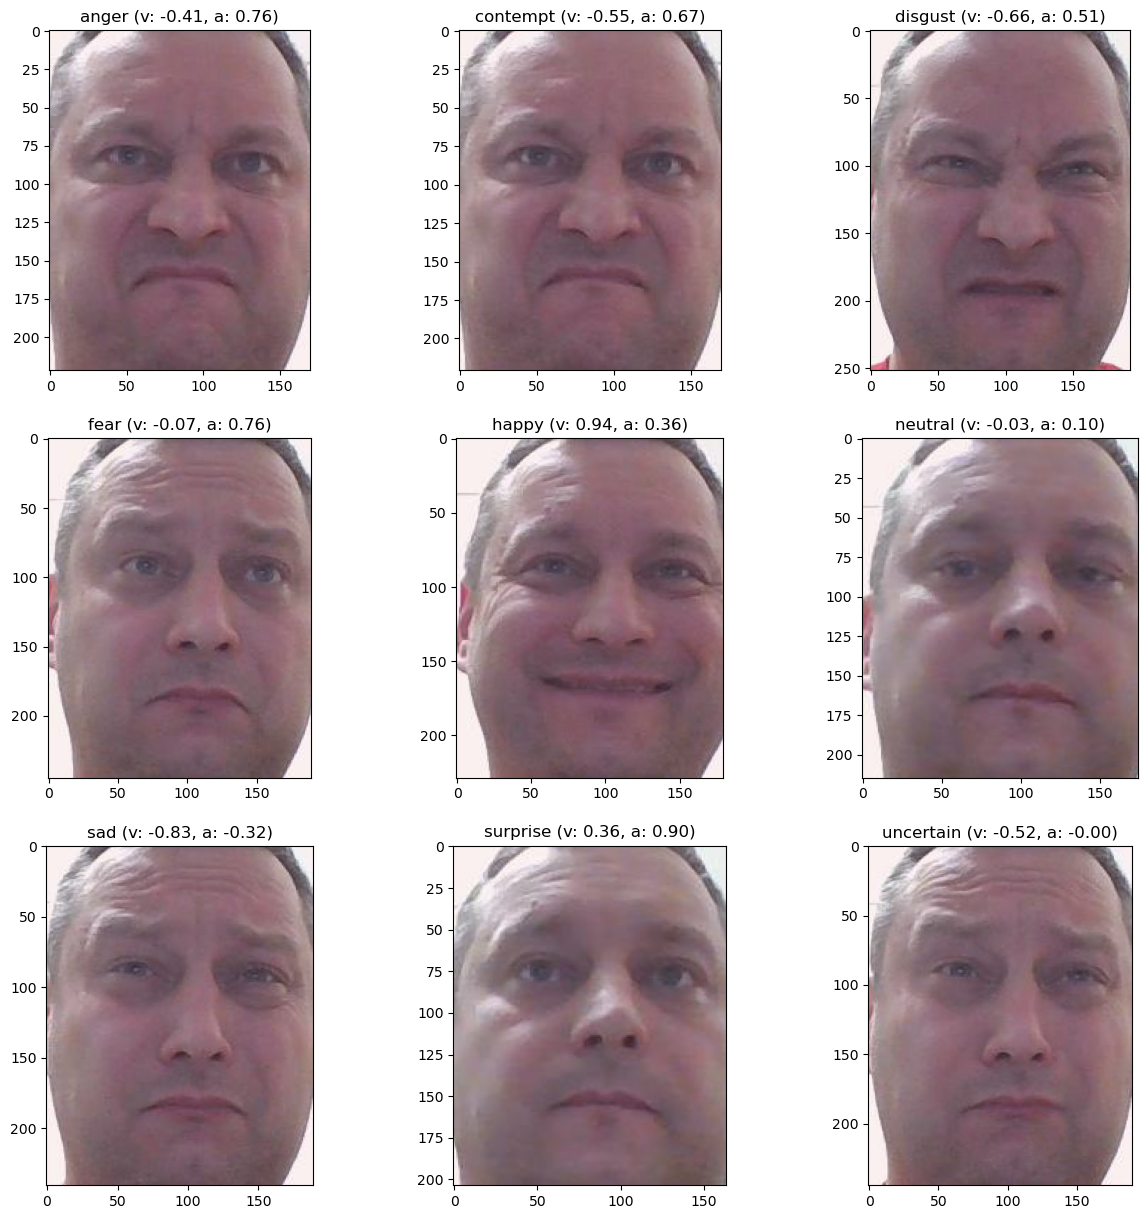

In [202]:
if pipeline.is_stage_complete:
    
    display(model_deploy_test)
    ncols = 3
    nrows = len(EMOTIONS) // ncols + (len(EMOTIONS) % ncols > 0)
    plt.figure(figsize=(ncols*5, nrows*5))
    if isinstance(EMOTIONS, (list, tuple)):
        for index, (emotion, (image_path, probability)) in enumerate(model_deploy_test.iterrows()):
            image = cv.cvtColor(cv.imread(image_path), cv.COLOR_BGR2RGB)
            plt.subplot(ncols, nrows, index+1)
            plt.imshow(image)
            plt.title(f'{emotion} ({probability:.2f})')
    else:
        for index, (emotion, (image_path, probability, valence, arousal)) in enumerate(model_deploy_test.iterrows()):
            image = cv.cvtColor(cv.imread(image_path), cv.COLOR_BGR2RGB)
            plt.subplot(ncols, nrows, index+1)
            plt.imshow(image)
            plt.title(f'{emotion} (v: {valence:.2f}, a: {arousal:.2f})')

### Pipeline Execution Report

In [203]:
display(pipeline.report)

,params,platform,start_time,update_time,state
stage,,,,,
train_feature_extraction,"{'path': 'train_features', 'flip': 'horizontal...",colab,2022-11-12 17:18:17.531360,2022-11-12 17:22:55.791206,complete
test_feature_extraction,"{'path': 'test_features', 'flip': 'horizontal'...",colab,2022-11-12 17:22:55.833397,2022-11-12 17:23:27.496146,complete
model_on_top_selection,"{'path': 'model_on_top_selection', 'batch_size...",local,2022-11-13 19:58:55.909665,2022-11-14 00:18:10.744507,complete
model_on_top_training,"{'path': 'model_on_top_training', 'flip': 'hor...",colab,2022-11-14 00:43:08.158678,2022-11-14 01:01:07.450754,complete
model_fine_tuning,"{'path': 'model_fine_tuning', 'batch_size': 32...",colab,2022-11-14 01:01:07.502873,2022-11-14 15:49:57.937375,complete
model_deploy_test,"{'path': 'model_deploy_test', 'scale_factor': ...",local,2022-11-28 23:40:31.445727,2022-11-28 23:45:29.030324,complete
